# Benchmark — heteroscedastic mixed-variable BO: model × acquisition comparison

Compares the **4 surrogate models** (Separate GP, Categorical kernel, Standard LVGP, Heteroscedastic
LVGP) × **6 acquisitions** (EI/LCB/PI + noise-aware HAEI/ANPEI/RAHBO) across the test problems.
The python-LVGP validation models are **excluded** here — they live in `compare_matlab_python.ipynb`.

**Structure**
1. **Setup & toggles** — load the grid, choose n_rep / acquisition / centering.
2. **Data coverage** — how many cells each comparison rests on.
3. **Convergence** — regret / value / σ² trajectories per problem (models overlaid).
4. **Summary heatmaps & final tables** — one-glance model × acquisition outcomes + compute cost.
5. **Per-problem deep dives** — full report, per-acquisition panels, LVGP latent spaces.
6. **Acquisition comparison** — rankings, noise & MV-robustness tables, seed distributions, exports.
7. **Model (surrogate) comparison** — the headline rankings (with the engine caveat).
8. **Model quality & robustness** — loop-light MAE/RRMSE/coverage/IS + robust-design MV.
9. **Exports** — Excel workbooks and paper-ready LaTeX.

## Part 1 — Setup & toggles
**What:** load every stored result cell into one `GridResults`; set the knobs used by every section.
**Why:** one switchboard — change `N_REP`, `ACF`, `GROUND_TRUTH`, or `CENTER` here and every plot
below follows; no per-cell editing.
**How:** `.npz` (python) and `.mat` (MATLAB) cells share one schema; aux python-LVGP models are
filtered at load. `GROUND_TRUTH=True` scores incumbents on the noise-free f (recommended);
`CENTER='median'` gives median ± IQR bands (robust to the heavy-tailed seeds).

In [1]:
import warnings; warnings.filterwarnings("ignore")
import sys, os; sys.path.insert(0, os.path.abspath('..'))
import numpy as np, matplotlib.pyplot as plt
from utils import problems as P
from utils.results import (GridResults, facet, heatmaps_by_function, final_regret_table,
                           coverage, runtime_table,
                           regret_heatmap,
                           problem_report, all_problem_reports, acquisition_facet, latent_space,
                           acquisition_tables, acquisition_ranking,
                           method_tables, method_ranking, method_acq_leaderboard,
                           style_best, style_best_combined, export_comparison_tables,
                           acq_method_regret_table, acq_method_table,
                           acq_method_heatmap, export_acq_method_excel,
                           export_latex_tables,
                           seed_boxplot, ecdf, head_to_head, mv_alpha_sweep)

grid = GridResults.load('../results')
# main benchmark = the 4 core models only; the python-LVGP (aux) models live in
# compare_matlab_python.ipynb, not here
from utils.models import MODELS as _MODELS
grid = GridResults(grid.root, [r for r in grid.runs if not _MODELS[r['model']].aux])
print('functions:', grid.functions())
print('models   :', grid.models())
print('cells    :', len(grid.runs))

functions: ['ackley_10d', 'ackley_2d', 'branin_hetero', 'golinski', 'griewank_2d', 'otl_circuit', 'piston', 'rastrigin_6d', 'sixhump_camel']
models   : ['categorical_kernel', 'heter_LVGP', 'separate_gp', 'standard_LVGP']
cells    : 5951


## The toggles

`GROUND_TRUTH` — how the **incumbent** (the "best design so far") is chosen, and what σ² means:

| | `True` | `False` |
|---|---|---|
| incumbent | argmin of the **noise-free** f | argmin of the **observed** replicate mean |
| σ² | the **true** noise variance σ(x,ℓ)² there | the **sample** variance of the replicates there |

This matters. The observed mean can dip *below* the true optimum f\* purely from noise (on branin,
`noisy_best = −3.16` against `f* = 0.465`), which makes a noisy "regret" look negative. `GROUND_TRUTH = True`
is the honest convergence measure; `False` shows what the optimizer actually saw.

`LOG_SCALE` applies to the regret and σ² convergence panels (not the value plot, which needs a linear axis
to show the f\* line).

In [2]:
GROUND_TRUTH = True         # <-- incumbent & sigma^2 by the noise-free f (see table above)
LOG_SCALE    = True         # <-- log y-axis on the regret / sigma^2 convergence panels
CENTER       = 'mean'       # <-- 'mean' (± s.e.) or 'median' (± IQR) on the convergence bands
NOISE_AWARE_ONLY = True    # <-- per-acquisition facet: False = all 6 acqs, True = only HAEI/ANPEI/RAHBO
ACF, PARAM   = 'ei', float('nan')
N_REP        = 10           # replicates per design point: the sweep runs 3 and 10
FUNCS        = grid.functions()          # or e.g. ['branin_hetero', 'ackley_2d']
ONE_D        = [f for f in FUNCS if P.get(f).d == 1]   # the 1-D problems (landscape views)
DONE         = [f for f in FUNCS if f in ('ackley_2d','branin_hetero','golinski',
                                          'griewank_2d','otl_circuit','sixhump_camel')]
                                         # ^ problems with the full 4x6x2x5 block; extend
                                         #   as piston/rastrigin/10-D complete
print(f'{len(FUNCS)} problems: {FUNCS}')


9 problems: ['ackley_10d', 'ackley_2d', 'branin_hetero', 'golinski', 'griewank_2d', 'otl_circuit', 'piston', 'rastrigin_6d', 'sixhump_camel']


## Part 2 — Data coverage
**What:** completed cells per (problem × model × acquisition × n_rep).
**Why:** before trusting any comparison, know how much evidence is under it — partially-filled
problems produce partially-trustworthy rows everywhere downstream.
**How:** file counts on disk vs the target grid; incomplete problems are visible immediately.

## What the plots are averaging over
The sweep is long-running, so check the seed count behind each curve before reading too much into it.
`0` means that cell has not been computed yet.

In [3]:
coverage(grid, n_rep=N_REP)

model                       Categorical kernel  Heteroscedastic LVGP  \
function      acq                                                      
ackley_10d    ANPEI(β=0.8)                   5                     0   
              EI                             5                     0   
              HAEI(γ=0.5)                    5                     0   
              LCB                            5                     2   
              PI                             5                     0   
              RAHBO(α=0.5)                   5                     1   
ackley_2d     ANPEI(β=0.8)                  30                    30   
              EI                            30                    30   
              HAEI(γ=0.5)                   30                    30   
              LCB                           30                    30   
              PI                            30                    30   
              RAHBO(α=0.5)                  30                    30   
branin_hetero ANPEI(β=0.8)                  30                    30   
              EI                            30                    30   
              HAEI(γ=0.5)                   30                    30   
              LCB                           30                    30   
              PI                            30                    30   
              RAHBO(α=0.5)                  30                    30   
golinski      ANPEI(β=0.8)                   5                     5   
              EI                             5                     5   
              HAEI(γ=0.5)                    5                     5   
              LCB                            5                     2   
              PI                             5                     5   
              RAHBO(α=0.5)                   5                     4   
griewank_2d   ANPEI(β=0.8)                  30                    30   
              EI                            30                    30   
              HAEI(γ=0.5)                   30                    30   
              LCB                           30                    30   
              PI                            30                    30   
              RAHBO(α=0.5)                  30                    30   
otl_circuit   ANPEI(β=0.8)                   5                     5   
              EI                             5                     5   
              HAEI(γ=0.5)                    5                     5   
              LCB                            5                     5   
              PI                             5                     5   
              RAHBO(α=0.5)                   5                     5   
piston        ANPEI(β=0.8)                   5                     5   
              EI                             5                     5   
              HAEI(γ=0.5)                    5                     5   
              LCB                            5                     5   
              PI                             5                     5   
              RAHBO(α=0.5)                   5                     5   
rastrigin_6d  ANPEI(β=0.8)                   5                     5   
              EI                             5                     5   
              HAEI(γ=0.5)                    5                     5   
              LCB                            5                     5   
              PI                             5                     5   
              RAHBO(α=0.5)                   5                     5   
sixhump_camel ANPEI(β=0.8)                  30                    30   
              EI                            30                    30   
              HAEI(γ=0.5)                   30                    30   
              LCB                           30                    30   
              PI                            30                    30   
              RAHBO(α=0.5)              

## Part 3 — Convergence (regret · value · noise-at-incumbent)
**What:** per-problem trajectories of the best-so-far, models overlaid, for the acquisition chosen in
the toggles: regret (log), raw value (with f\*), and the TRUE noise σ² at the incumbent design.
**Why:** the classic BO question — *how fast* does each surrogate find good designs, and does its
incumbent sit in a quiet (low-σ²) or noisy region while it converges.
**How:** `true_best_sampled` = running best of the noise-free f over sampled points; bands =
median ± IQR (or mean ± s.e.) over seeds. **Caveat:** the two MATLAB models run in a different BO
loop than the two python models, so *cross-engine* regret gaps partly reflect the loop — the
loop-light metrics in Part 8 are the fair model-vs-model view.

## Convergence — REGRET (value − f\*)
One panel per problem, the 4 models overlaid: mean ± standard error over seeds. Lower is better.
With `GROUND_TRUTH = True` regret is guaranteed ≥ 0, so the log axis is meaningful.

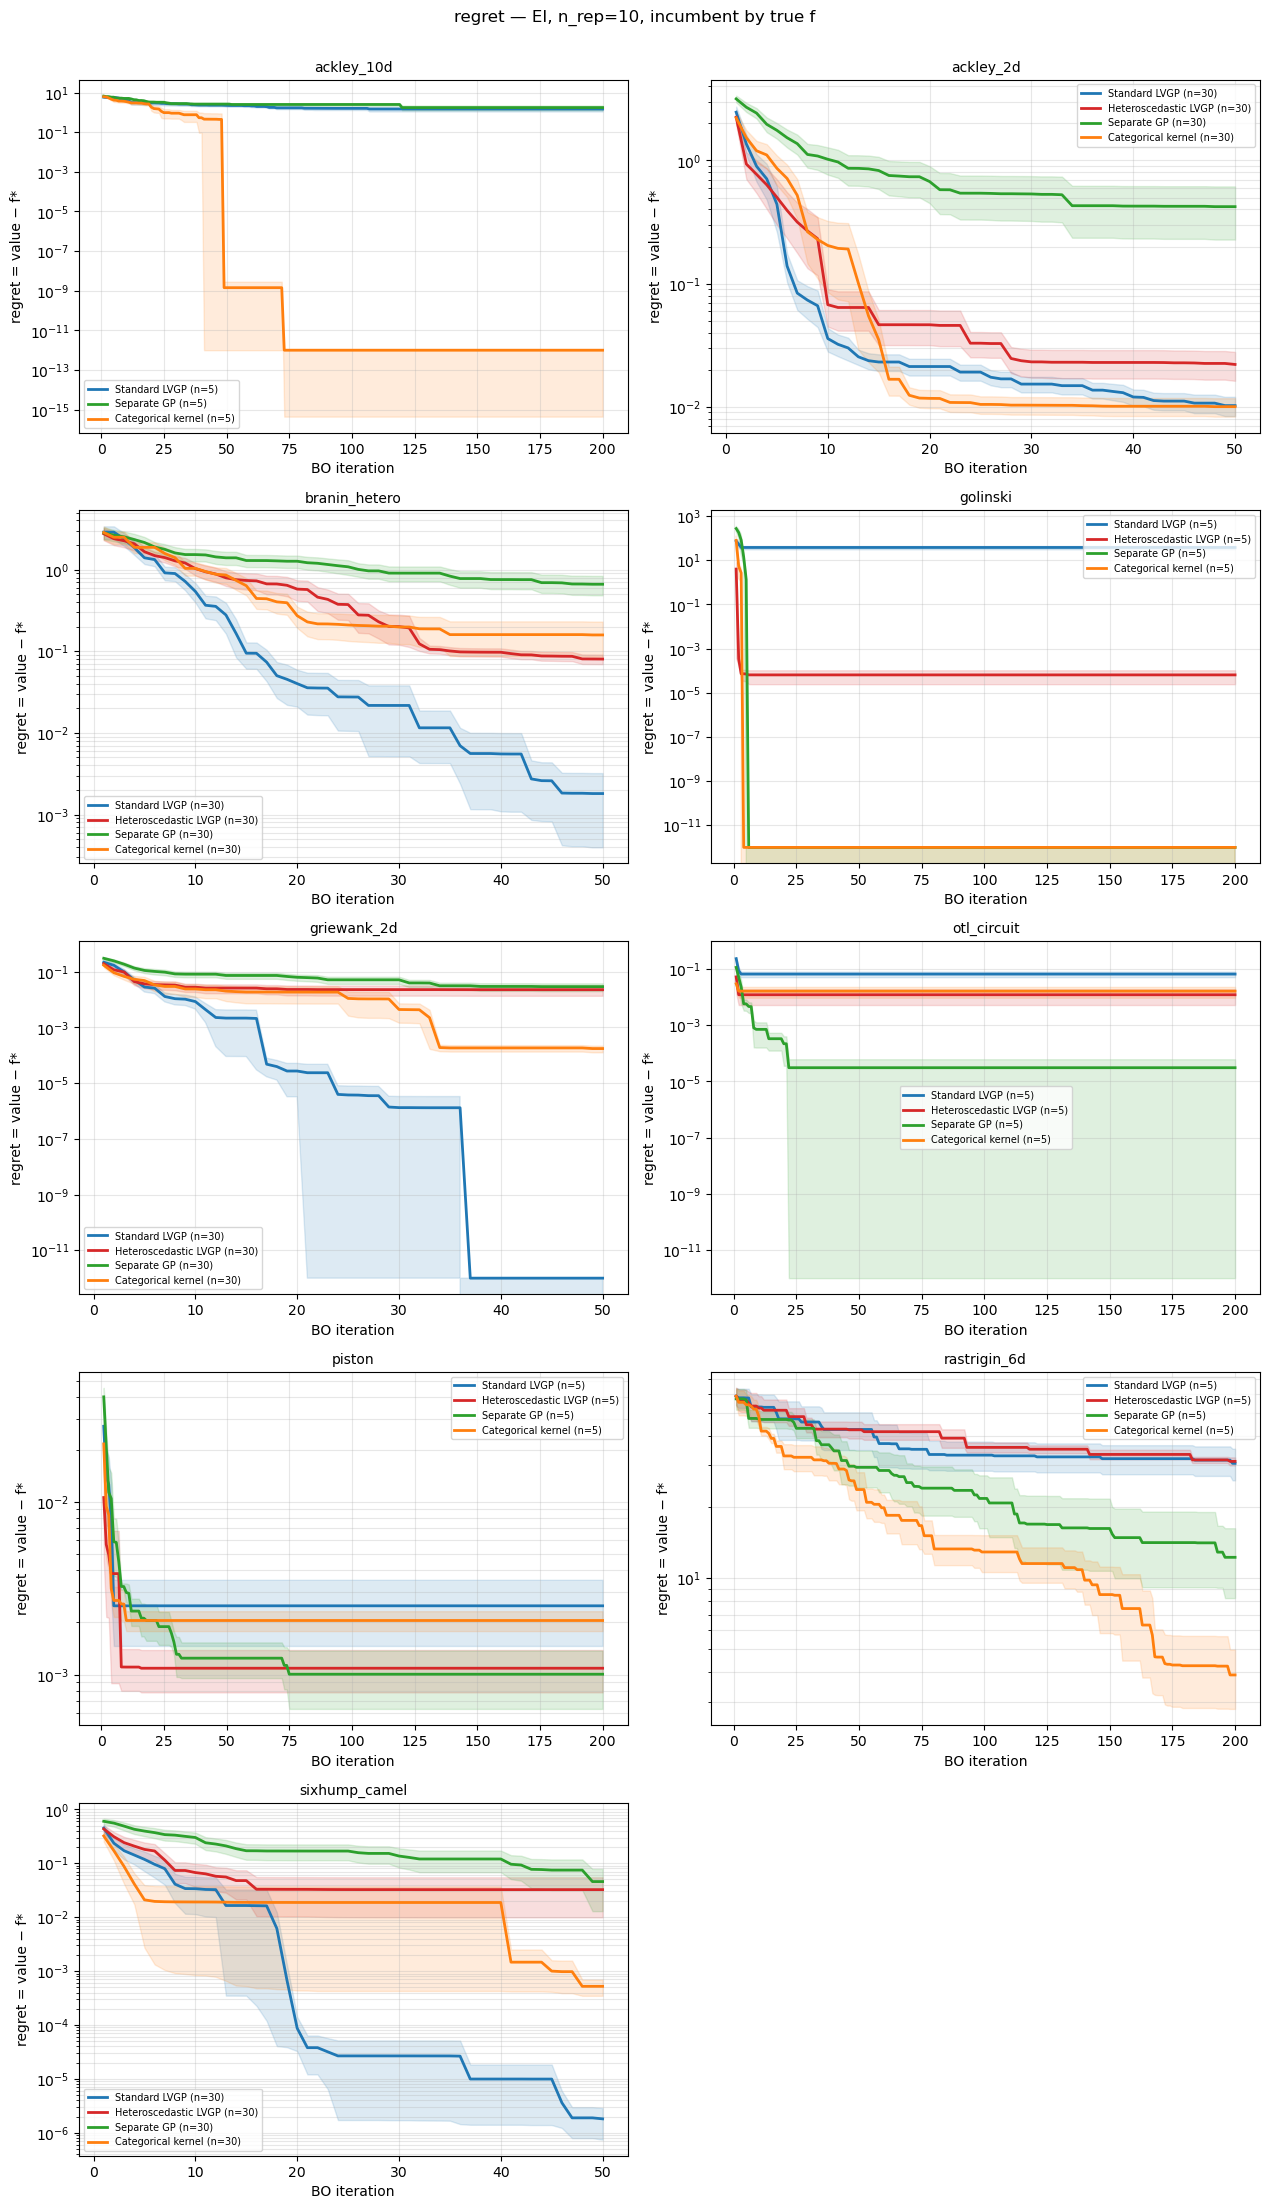

In [4]:
facet(grid, 'regret', functions=FUNCS, acf=ACF, param=PARAM, n_rep=N_REP,
      ground_truth=GROUND_TRUTH, logy=LOG_SCALE, center=CENTER);

## Convergence — VALUE, with the true optimum f\* as a horizontal line
The same runs on a linear axis, showing how close each model's best design gets to f\* (dashed grey).

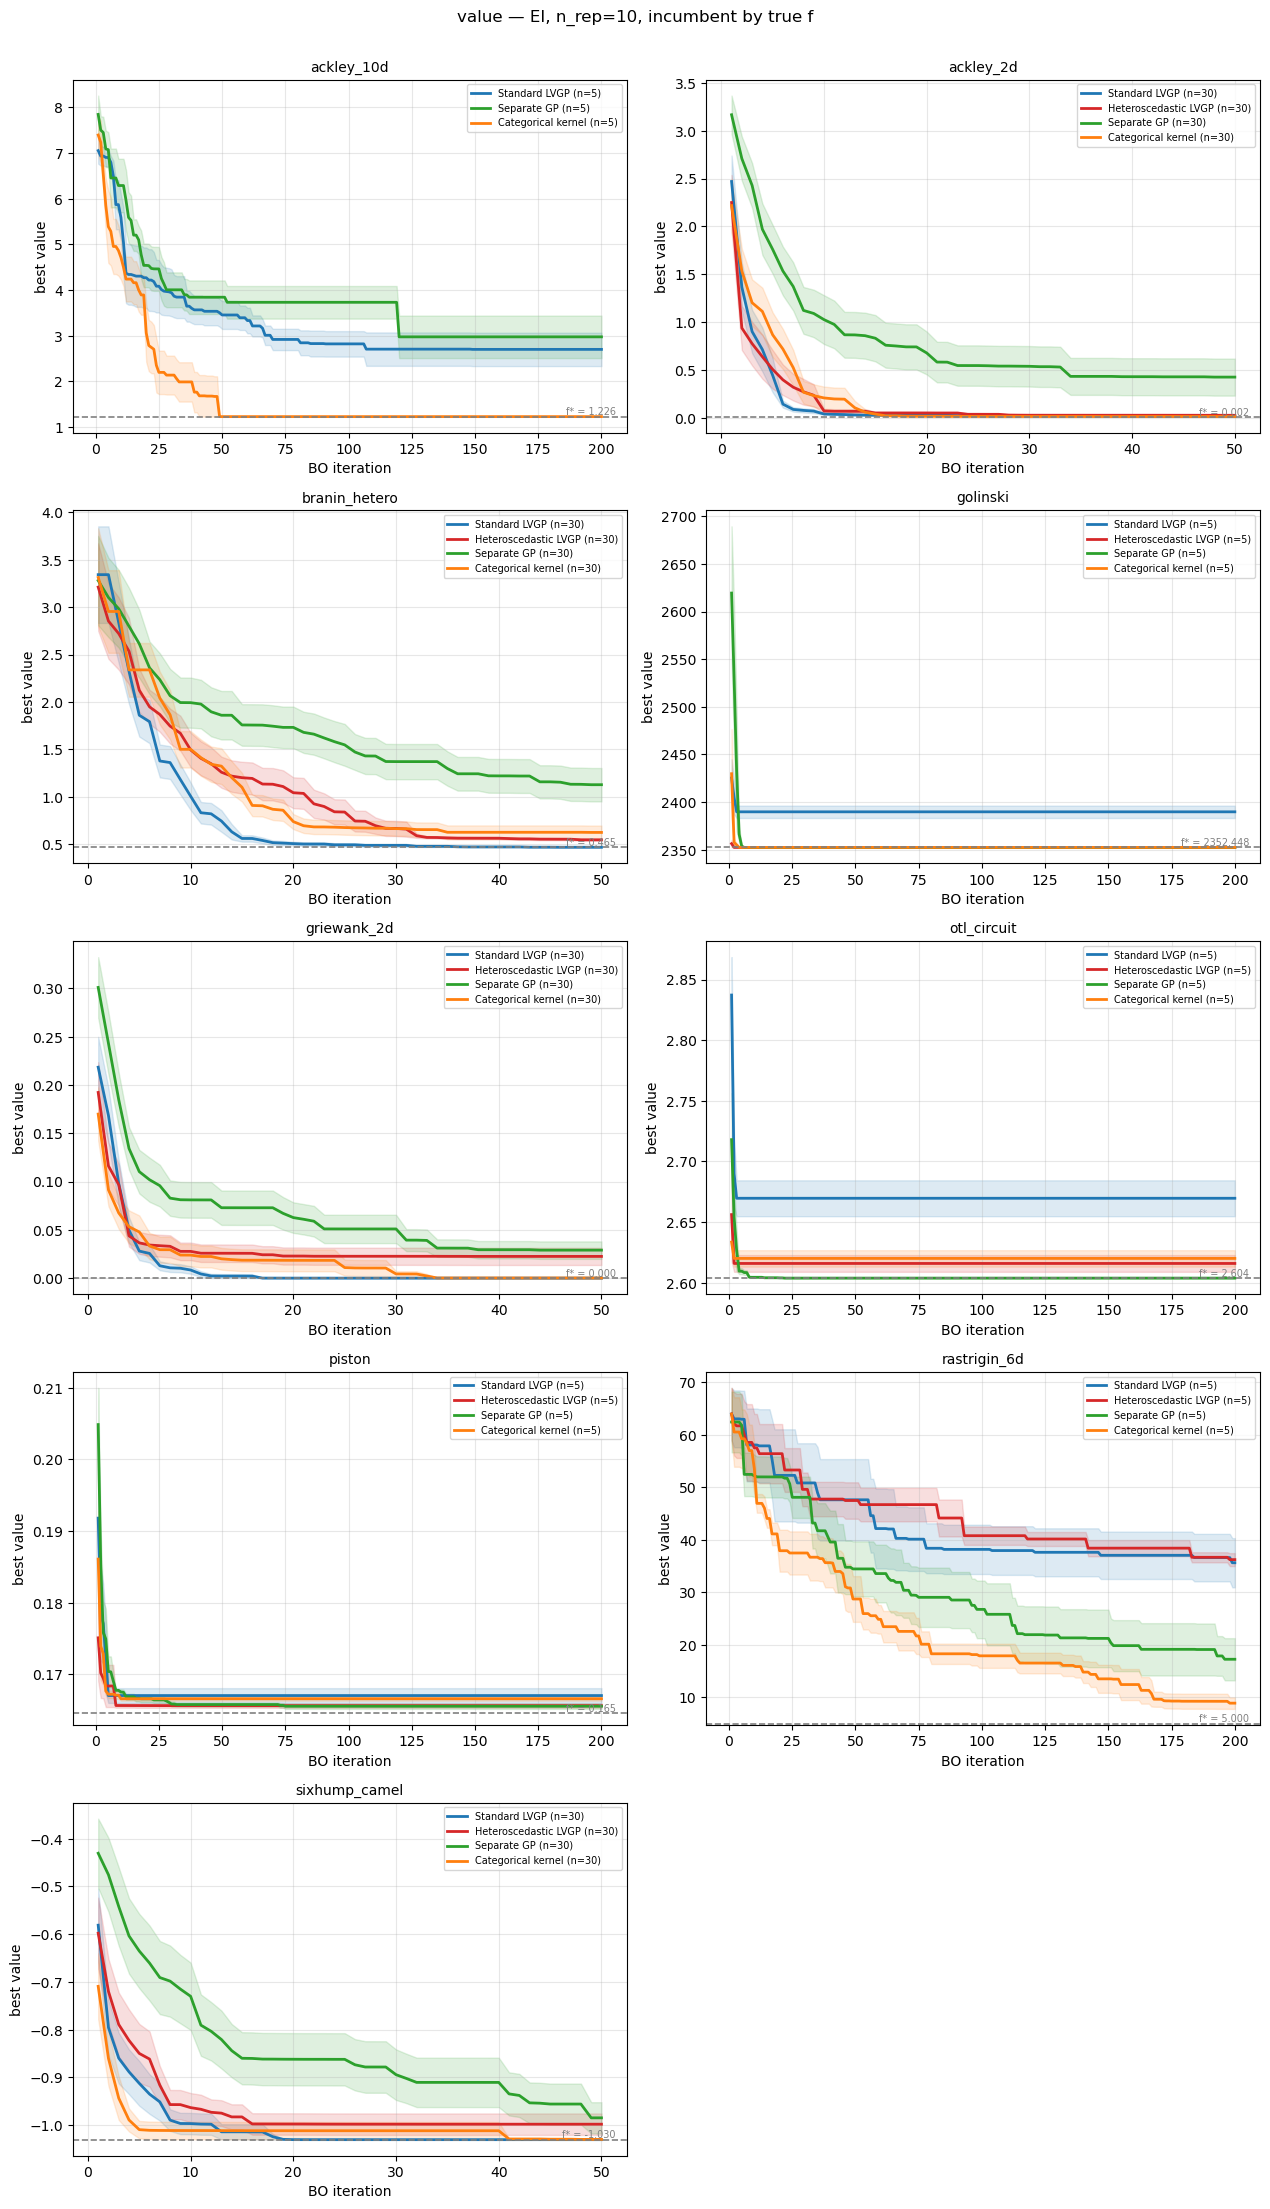

In [5]:
facet(grid, 'value', functions=FUNCS, acf=ACF, param=PARAM, n_rep=N_REP,
      ground_truth=GROUND_TRUTH, logy=False, center=CENTER);

## Noise variance σ² at the incumbent best design
The heteroscedastic question: *does the model end up recommending a design that sits in a noisy region?*
A noise-aware model should settle on a **lower σ²** incumbent, all else equal. With `GROUND_TRUTH = True`
this is the true σ(x,ℓ)² at the incumbent — not an estimate.

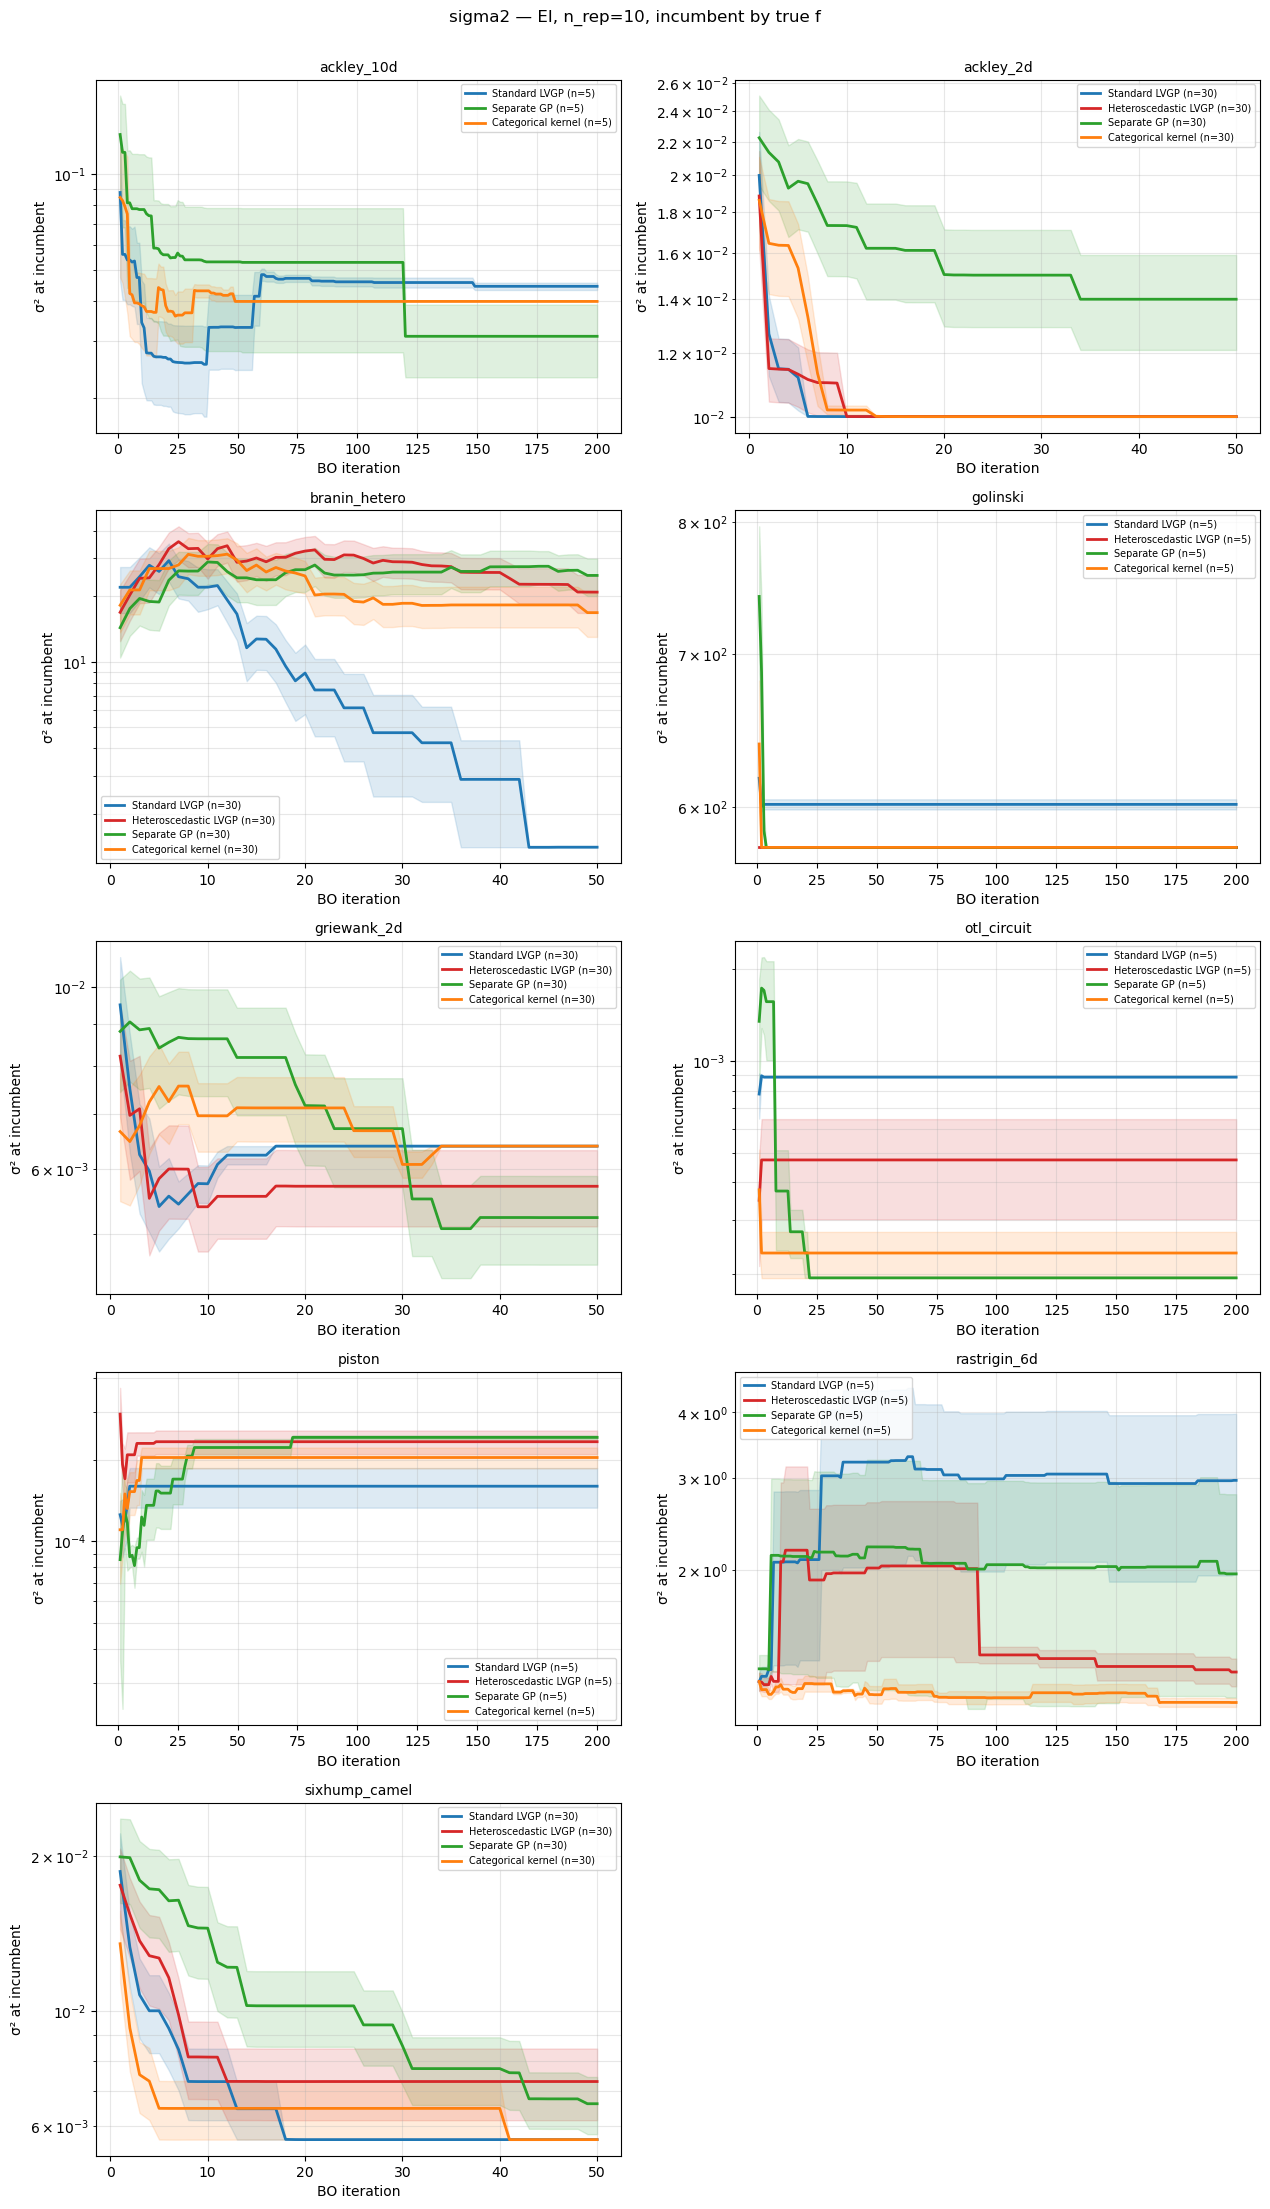

In [6]:
facet(grid, 'sigma2', functions=FUNCS, acf=ACF, param=PARAM, n_rep=N_REP,
      ground_truth=GROUND_TRUTH, logy=LOG_SCALE, center=CENTER);

## Part 4 — Summary heatmaps & final tables
**What:** final-outcome heatmaps (acquisition × model, one per problem), a consolidated all-problem
heatmap, the final-regret table, and wall-clock cost per cell.
**Why:** the one-glance answer to "which (model, acquisition) pairs work where" — and what each
model costs, since a small accuracy edge may not justify 10× the compute.
**How:** final-iteration metric aggregated over seeds (viridis, darker = better); runtimes come from
each cell's stored `runtime` (MATLAB cells ran on vision, python on vision — comparable).

## Summary heatmaps — acquisition × model, one per problem
Final regret for every acquisition actually present in the results. Acquisition rows with no data anywhere
are dropped, so there are no blank bands. Darker = better (lower regret).

Note `standard_LVGP` only supports the noise-blind acquisitions (ei/lcb/pi) by construction, so its
haei/anpei/rahbo entries are legitimately empty.

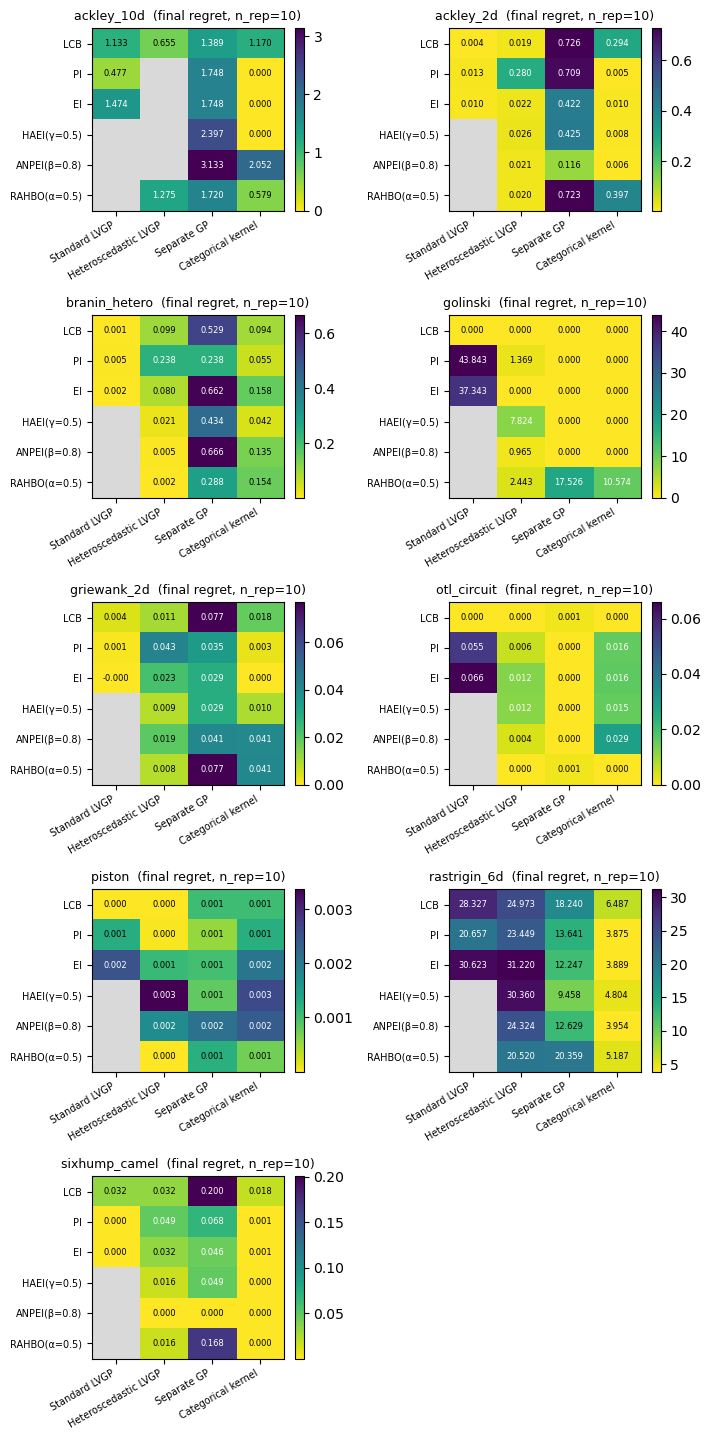

In [7]:
heatmaps_by_function(grid, functions=FUNCS, n_rep=N_REP, ground_truth=GROUND_TRUTH);

### Consolidated regret heatmap — every model / acquisition / problem in one figure
Same numbers as the per-problem heatmaps above, but stacked into a single view so you can scan
model-vs-acquisition across all problems at once. **Each cell is annotated with the mean final regret.**

Since the problems span orders of magnitude in regret, a shared raw color scale would be useless, so
**color is normalized within each row**: green = best model for that (problem, acquisition), red = worst.
The printed number is the true regret. Grey = no data (e.g. Standard LVGP has no noise-aware acquisitions).
Set `normalize='func'` to make colors comparable across a problem's acquisitions instead of per-row.

In [8]:
# regret_heatmap(grid, functions=FUNCS, n_rep=N_REP, ground_truth=GROUND_TRUTH, normalize='row');

## Final-regret summary table (problem × model)

In [9]:
final_regret_table(grid, acf=ACF, param=PARAM, n_rep=N_REP)

,Categorical kernel,Heteroscedastic LVGP,Separate GP,Standard LVGP
ackley_10d,0.000 ± 0.000,None,1.748 ± 0.930,1.474 ± 0.732
ackley_2d,0.010 ± 0.009,0.022 ± 0.031,0.422 ± 1.044,0.010 ± 0.010
branin_hetero,0.158 ± 0.390,0.080 ± 0.058,0.662 ± 0.950,0.002 ± 0.008
golinski,0.000 ± 0.000,0.000 ± 0.000,0.000 ± 0.000,37.343 ± 12.999
griewank_2d,0.000 ± 0.000,0.023 ± 0.048,0.029 ± 0.049,-0.000 ± 0.000
otl_circuit,0.016 ± 0.014,0.012 ± 0.014,0.000 ± 0.000,0.066 ± 0.030
piston,0.002 ± 0.001,0.001 ± 0.001,0.001 ± 0.001,0.002 ± 0.002
rastrigin_6d,3.889 ± 2.193,31.220 ± 2.467,12.247 ± 8.040,30.623 ± 9.368
sixhump_camel,0.001 ± 0.001,0.032 ± 0.121,0.046 ± 0.177,0.000 ± 0.000


## Cost — mean wall-clock seconds per cell
The two MATLAB LVGP models dominate the sweep's runtime; the python GPs are an order of magnitude cheaper.

model,Categorical kernel,Heteroscedastic LVGP,Separate GP,Standard LVGP
function,,,,
ackley_10d,11586.6,79121.9,4102.0,78272.9
ackley_2d,73.4,410.9,18.8,396.5
branin_hetero,113.8,750.3,44.5,676.4
golinski,2587.1,24925.1,1712.1,26264.9
griewank_2d,54.2,312.7,17.7,312.6
otl_circuit,3998.9,16472.4,1181.8,15570.6
piston,5347.5,21692.2,2351.1,18683.7
rastrigin_6d,6601.9,17541.8,1575.4,18042.1
sixhump_camel,58.2,312.9,20.5,305.3


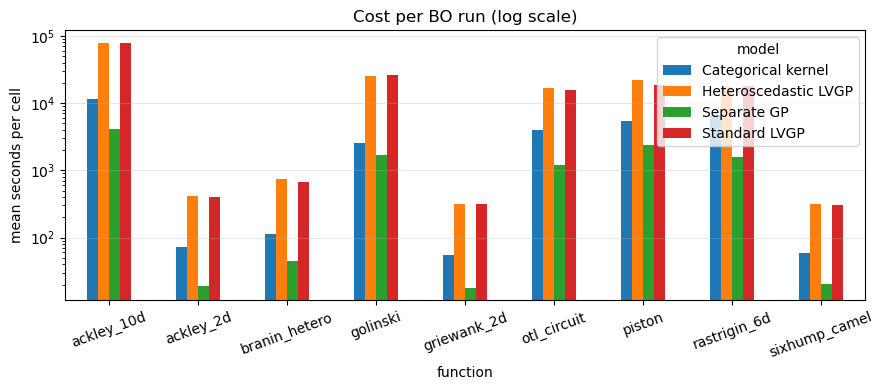

In [10]:
rt = runtime_table(grid)
display(rt)
ax = rt.plot(kind='bar', figsize=(9, 4), rot=20)
ax.set_ylabel('mean seconds per cell'); ax.set_yscale('log')
ax.set_title('Cost per BO run (log scale)'); ax.grid(alpha=0.3, axis='y'); plt.tight_layout()

## Reading these plots

- **Regret vs σ²** are the two axes of the heteroscedastic trade-off. A model can win on regret while
  parking the incumbent in a high-noise region (bad if you must *deploy* that design), or vice versa.
- **`standard_LVGP` is noise-blind**: it never sees the replicate variance, so any advantage it shows on a
  noise-blind acquisition (ei/lcb/pi) is a fair comparison, but it cannot run haei/anpei/rahbo at all.
- Flip **`GROUND_TRUTH = False`** to see the optimizer's own view. Regret can go negative there — that is
  the noise, not a bug.
- Change `N_REP` between 3 and 10 to see how replicate count changes the variance estimate each model works
  from — the whole point of the heteroscedastic setup.

## Part 5 — Per-problem deep dives
**What:** for one chosen problem — the 4-figure report (convergence, per-acquisition, noise,
latent space), per-acquisition panels with shared y-axis, and the LVGP latent-space check; then the
same report auto-saved for every problem under `plots/<problem>/`.
**Why:** the aggregate tables say *which* model wins; these show *why* — e.g. whether LVGP's latent
embedding actually recovers the true similarity between categorical levels (Spearman ρ), or whether
a model camps on a noisy level.
**How:** set `function` in the cell; `latent_space` compares learned z-distances to true level
distances; reports are regenerated from stored cells only.

---
# Per-problem 

Everything above compares *across* problems. This section zooms into **one problem at a time** and
assesses every model / acquisition on it, with a consistent visual grammar so the encoding is learned once:

- **acquisition → colour**, **model → line style + marker** (in the panels that overlay both).

`problem_report(grid, function, ...)` produces two figures:

**overview** (6 panels)
1. the problem **landscape + initial DOE** — noise-free f(x1│level) per category, the true ±1σ noise band,
   the global optimum (★), and the shared SLHD design with its noisy replicates;
2. **regret** convergence (models, one acquisition);
3. **value** convergence with the f\* line;
4. **σ²** at the incumbent;
5. **all models × all acquisitions** on one regret axis (acq = colour, model = style);
6. **regret vs noise trade-off** — final regret against σ² at the incumbent; lower-left is the sweet spot.

**exploration** — the actual **sampling trajectory** of each model (x1 vs BO iteration, coloured by the
chosen categorical level, red line = the optimum's x1). This shows exploration-vs-exploitation and whether
a model locks onto the right category / x1.

`acf`/`param` fix the single acquisition used in panels 2–4 and the exploration figure; panels 5–6 sweep all
acquisitions.

> **How regret is computed here (and why it only steps *down*).**
> `regret(t) = [ best value among the first n_init + t sampled points ] − f*`, a **cumulative minimum**,
> so it is monotonic — it never rises. The visible steps are the best-so-far staircase (flat until a new
> best is sampled, then a drop), not noise. The `GROUND_TRUTH` toggle chooses what "best value" means:
> - **`True`** (default, and the case of interest here): the **noiseless** f(x, level) evaluated at each
>   sampled x — "sample the real value at the x locations, keep the best". Verified monotonic (0 up-jumps).
> - **`False`**: the **observed replicate mean** at each sampled x — "best across the mean".
>
> The only panel that legitimately rises and falls is **σ² at the incumbent** — that is not a best-so-far
> quantity: as the incumbent design changes, the noise level there can go up or down.

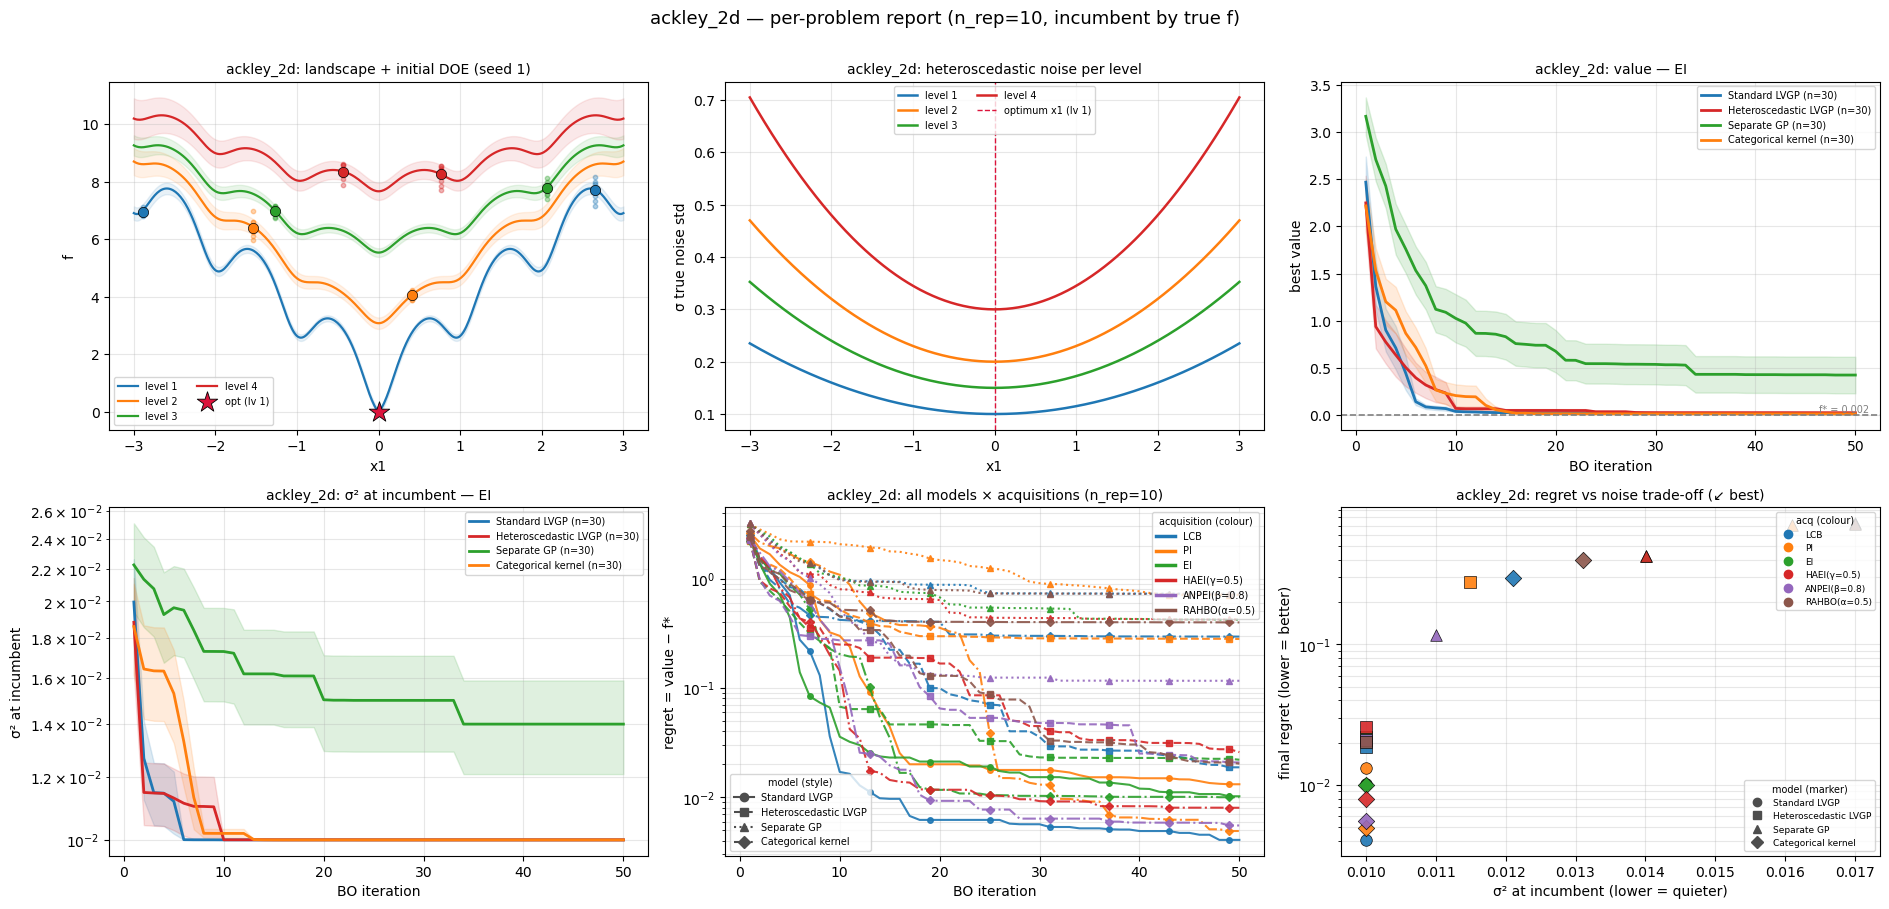

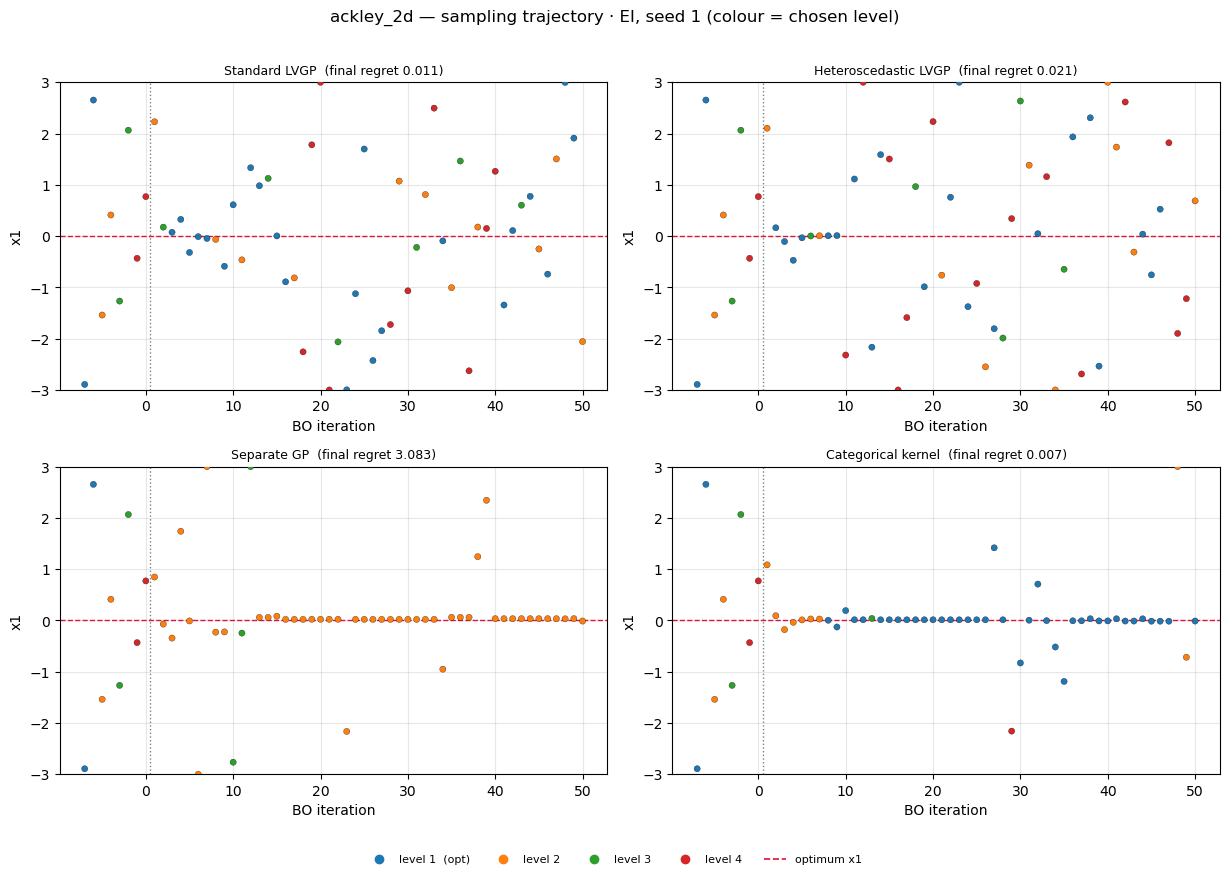

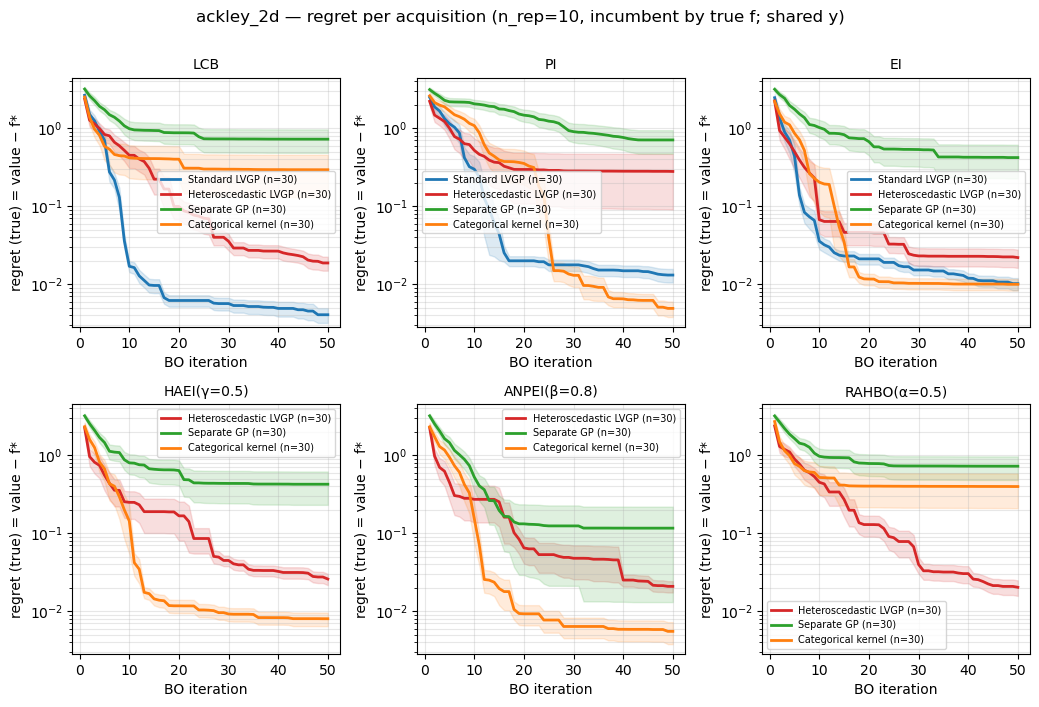

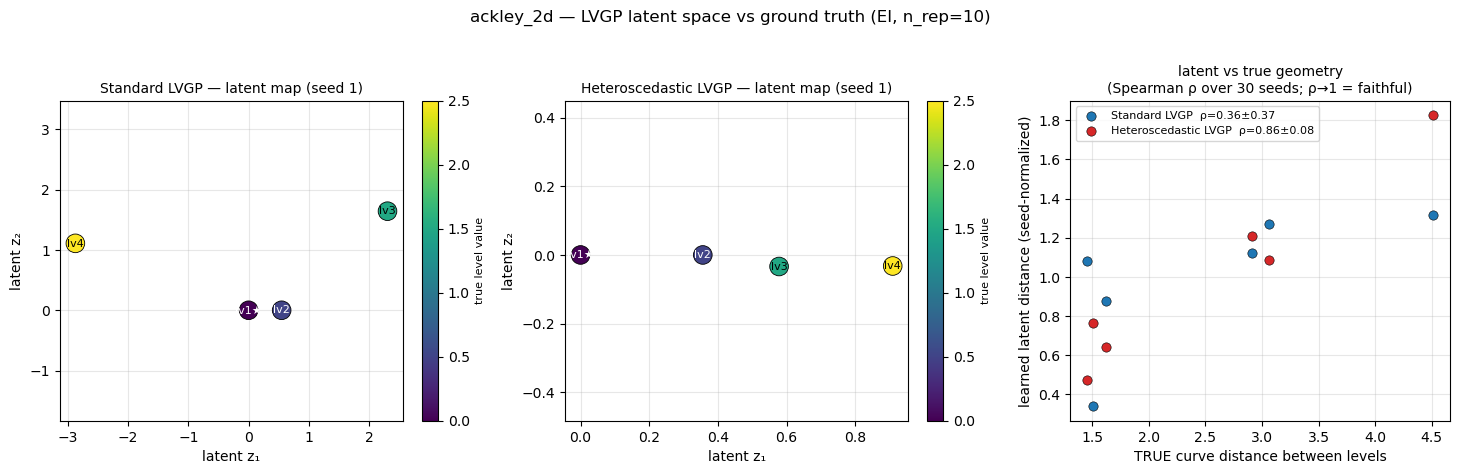

In [11]:
FOCUS = FUNCS[1]           # <-- pick any problem to inspect inline; e.g. 'ackley_2d'
problem_report(grid, FOCUS, acf=ACF, param=PARAM, n_rep=N_REP,
               ground_truth=GROUND_TRUTH, seed=1, show=True);

### Regret per acquisition — one panel per acquisition, models overlaid (shared y-axis)
For the focus problem: a panel for each acquisition, overlaying every model's regret convergence
(mean ± s.e., colour = model). **All panels share one y-range**, so you can compare acquisitions directly
— e.g. which acquisition drives a given model lowest. The bottom row (haei/anpei/rahbo) has no Standard
LVGP line because that model is noise-blind. This is also saved per problem as `by_acquisition.png`.

> Set `NOISE_AWARE_ONLY = True` in the toggles cell to show only the noise-aware acquisitions (HAEI, ANPEI, RAHBO) instead of all 6.


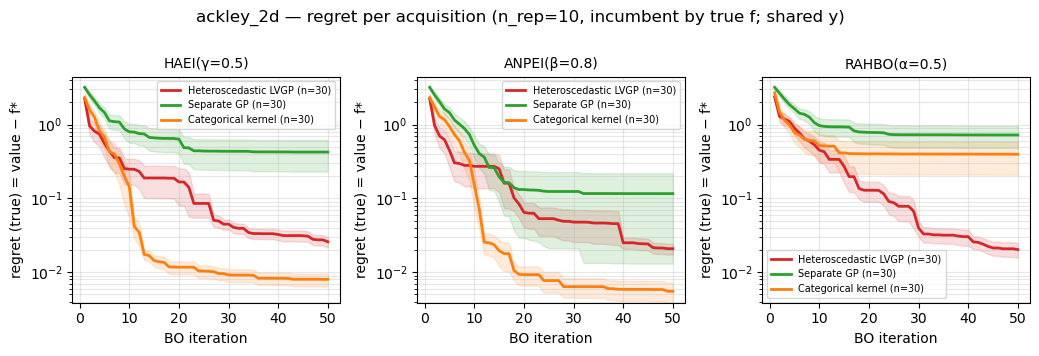

In [12]:
acquisition_facet(grid, FOCUS, n_rep=N_REP, ground_truth=GROUND_TRUTH,
                  share_y=True, noise_aware_only=NOISE_AWARE_ONLY, center=CENTER);


### LVGP latent space vs ground truth
LVGP maps each categorical level to a 2-D latent point **z** — levels that behave similarly under the
true objective should land close together. Only the LVGP models expose this (`hyper.z`); the python GPs
have no such embedding.

- **Latent map** (one panel per LVGP model, one seed): each level's learned z, annotated (★ = optimal
  level), coloured by its **true underlying value** (`cat_values`). A smooth colour gradient means the
  embedding recovered the true ordering.
- **Recovery panel** (pooled over all seeds): a **rank–rank** plot of the learned latent distance vs the
  **true** distance between level pairs (RMS gap between their noise-free curves). The LVGP embedding is
  identifiable only up to rotation/reflection/**scale**, so an isometry (y=x on raw distances) is *not* a
  meaningful target — only the *ordering* of distances is. On rank–rank axes the **dashed diagonal is
  exactly perfect fidelity (Spearman ρ=1)**: points on it = pairs ordered correctly, points off it = pairs
  the embedding got out of order. Saved per problem as `latent_space.png`.

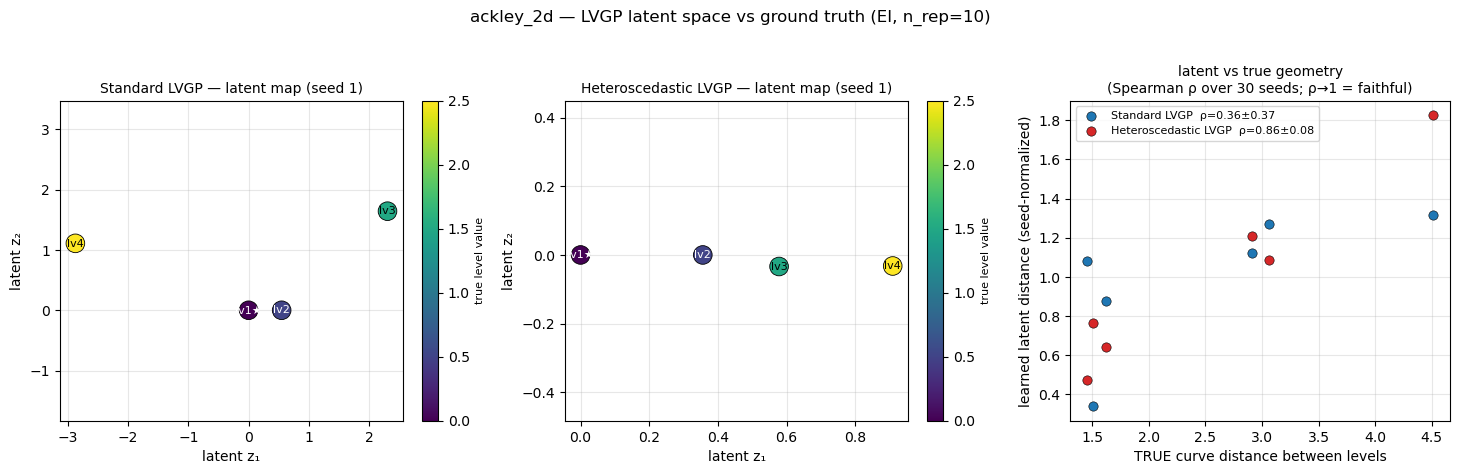

In [13]:
latent_space(grid, FOCUS, acf=ACF, param=PARAM, n_rep=N_REP, seed=1);

### Generate the same report for **every** problem → `plots/<problem>/`
Writes `overview.png` + `exploration.png` under `notebooks/plots/<problem>/` for each test problem, so you
have them as files without cluttering the notebook. `show=False` keeps the batch output clean.

In [14]:
all_problem_reports(grid, functions=FUNCS, save_root='plots',
                    acf=ACF, param=PARAM, n_rep=N_REP, ground_truth=GROUND_TRUTH,
                    seed=1, noise_aware_only=True);


  wrote plots/ackley_10d/overview.png + exploration.png + by_acquisition.png + latent_space.png
  wrote plots/ackley_2d/overview.png + exploration.png + by_acquisition.png + latent_space.png
  wrote plots/branin_hetero/overview.png + exploration.png + by_acquisition.png + latent_space.png
  wrote plots/golinski/overview.png + exploration.png + by_acquisition.png + latent_space.png
  wrote plots/griewank_2d/overview.png + exploration.png + by_acquisition.png + latent_space.png
  wrote plots/otl_circuit/overview.png + exploration.png + by_acquisition.png + latent_space.png
  wrote plots/piston/overview.png + exploration.png + by_acquisition.png + latent_space.png
  wrote plots/rastrigin_6d/overview.png + exploration.png + by_acquisition.png + latent_space.png
  wrote plots/sixhump_camel/overview.png + exploration.png + by_acquisition.png + latent_space.png


#### Ground truth first: WHERE is the robust optimum? (the RAHBO Fig-1 view)

**What is being computed.** Every design $x$ (at level $\ell$) has two ground-truth properties: its
objective value $f(x,\ell)$ and its noise level $\sigma^2(x,\ell)$ (how much repeated evaluations of
that design scatter). The **mean–variance objective** combines them into one number:

$$\mathrm{MV}_\alpha(x,\ell) \;=\; f(x,\ell) \;+\; \alpha\,\sigma^2(x,\ell)$$

- $f$: what you gain on average by using this design (lower = better here).
- $\alpha\,\sigma^2$: a **risk penalty** — how much you are punished for the design being unreliable.
- $\alpha$: the **risk weight**, i.e. how much you care about consistency vs raw performance.
  $\alpha=0$ → you only care about the average (the *nominal* optimum, $\arg\min f$).
  Larger $\alpha$ → you increasingly prefer a slightly worse but *quiet* design (the *robust* optimum,
  $\arg\min \mathrm{MV}_\alpha$).

**Why this matters.** A manufactured design experiences its noise every time it is used — picking the
lowest-$f$ design in a noisy region means real-world performance varies wildly. This is the premise of
the RAHBO paper (Makarova et al., 2021): their Fig. 1 shows exactly this landscape — two minima, the
lower one noisy — and their method optimizes $\mathrm{MV}$ instead of $f$. **Everything here is
computed from the TRUE $f$ and $\sigma$** (no models involved) — it is the *answer key* the models in
the rest of this section are graded against.

**How to read the two artifacts:**

- **Table (`mv_optima_table`)** — for each problem and each $\alpha$: the global minimizer of
  $\mathrm{MV}_\alpha$ (its level, $x_1$, and its $f$, $\sigma^2$, MV values). Read DOWN an
  $\alpha$-column: if level/x stay constant, robustness never changes the answer; if they **jump**,
  the problem contains a genuine robustness trap.
- **Landscape (`mv_landscape`)** — one panel per categorical level; each curve is
  $\mathrm{MV}_\alpha(x)$ for $\alpha\in\{0,1,5,15\}$ (the $\alpha=0$ curve IS $f(x)$).
  A dot marks each curve's per-level minimum; the **star** marks the global optimum for that
  $\alpha$. Regions where the curves fan apart as $\alpha$ grows are the noisy regions
  ($\sigma^2$ large); where all four curves lie on top of each other, the function is quiet.

**What OUR data shows (conclusions):**

| problem | nominal opt ($\alpha$=0) | robust opt ($\alpha$=15) | verdict |
|---|---|---|---|
| branin_hetero | lv2, x=3.18 (f=0.465, σ²=1.41) | **lv4**, x=3.18 (f=5.45, σ²=0.72) | **trap** — switches level at α≈7 |
| griewank_2d | lv1, x=0 (σ²=0.0064) | **lv2**, x=0 (f=0.062, σ²=0.0016) | **trap** (mild) — switches at α≈13 |
| golinski | lv1 (f=2352, σ²=576) | **lv2** (f=2622, σ²=400) | **trap** — switches already at α=5 |
| sixhump_camel | lv3, x=−0.09 (σ²=0.0056) | unchanged | control — nominal opt already quiet |
| ackley_2d | lv1, x=0 (σ²=0.01) | unchanged | control — robustness is free |

1. **Only branin, griewank and golinski actually test robustness** — on them, a noise-blind method
   that perfectly optimizes $f$ still recommends the *wrong* design once risk matters. Camel and
   ackley are control problems: every method lands on a quiet optimum there, so they can't separate
   robust from non-robust models.
2. **The trap is a LEVEL switch, not an x shift** — the robust optimum relocates to a different
   categorical level (branin lv2→lv4, keeping x≈3.18). So robustness here is really a *category
   identification* task, exactly what the LVGP latent space is supposed to capture.
3. **Note our sweep runs RAHBO with $\alpha=0.5$** — below every switch threshold, so at that risk
   weight the robust and nominal optima *coincide* on all problems. The α-sensitivity sweep below
   ($\alpha\in\{1,5,15\}$) is therefore where the real robustness discrimination happens; judge the
   models there against THIS table's answers.
4. **Cross-check with the recommendation landscape further below**: a genuinely robust model's final
   recommendations should sit on this table's optima (for the α its acquisition encodes) — a model
   whose markers sit on branin's lv2 x≈9.4 region (low f, huge σ²) has been caught by the trap.


In [15]:
from utils.results import mv_optima_table, mv_landscape
mv_optima_table(functions=[f for f in FUNCS if f not in ("ackley_10d","griewank_10d")])

level       x1     f_true    sigma2         MV
problem       alpha                                                
ackley_2d     0.0        1    0.000     0.0000    0.0100     0.0000
              1.0        1    0.000     0.0000    0.0100     0.0100
              5.0        1    0.000     0.0000    0.0100     0.0500
              15.0       1    0.000     0.0000    0.0100     0.1500
branin_hetero 0.0        2    3.182     0.4651    1.4087     0.4651
              1.0        2    3.145     0.4721    1.3937     1.8658
              5.0        2    3.014     0.6182    1.3439     7.3378
              15.0       4    3.179     5.4499    0.7179    16.2189
golinski      0.0        1    2.600  2352.4478  576.0000  2352.4478
              1.0        1    2.600  2352.4478  576.0000  2928.4478
              5.0        2    2.600  2622.4741  400.0000  4622.4741
              15.0       2    2.600  2622.4741  400.0000  8622.4741
griewank_2d   0.0        1    0.000     0.0000    0.0064     0.0000
              1.0        1    0.000     0.0000    0.0064     0.0064
              5.0        1    0.000     0.0000    0.0064     0.0320
              15.0       2    0.000     0.0619    0.0016     0.0859
otl_circuit   0.0        4  145.215     2.7529    0.0002     2.7529
              1.0        4  145.215     2.7529    0.0002     2.7531
              5.0        4  145.215     2.7529    0.0002     2.7539
              15.0       4  145.215     2.7529    0.0002     2.7559
piston        0.0        4   32.000     0.1715    0.0002     0.1715
              1.0        4   32.000     0.1715    0.0002     0.1717
              5.0        4   32.000     0.1715    0.0002     0.1726
              15.0       4   32.000     0.1715    0.0002     0.1748
rastrigin_6d  0.0        1    0.000    15.0000    1.0000    15.0000
              1.0        1    0.000    15.0000    1.0000    16.0000
              5.0        1    0.000    15.0000    1.0000    20.0000
              15.0       1    0.000    15.0000    1.0000    30.0000
sixhump_camel 0.0        3   -0.088    -1.0303    0.0056    -1.0303
              1.0        3   -0.088    -1.0303    0.0056    -1.0247
              5.0        3   -0.088    -1.0303    0.0056    -1.0022
              15.0       3   -0.088    -1.0303    0.0056    -0.9458

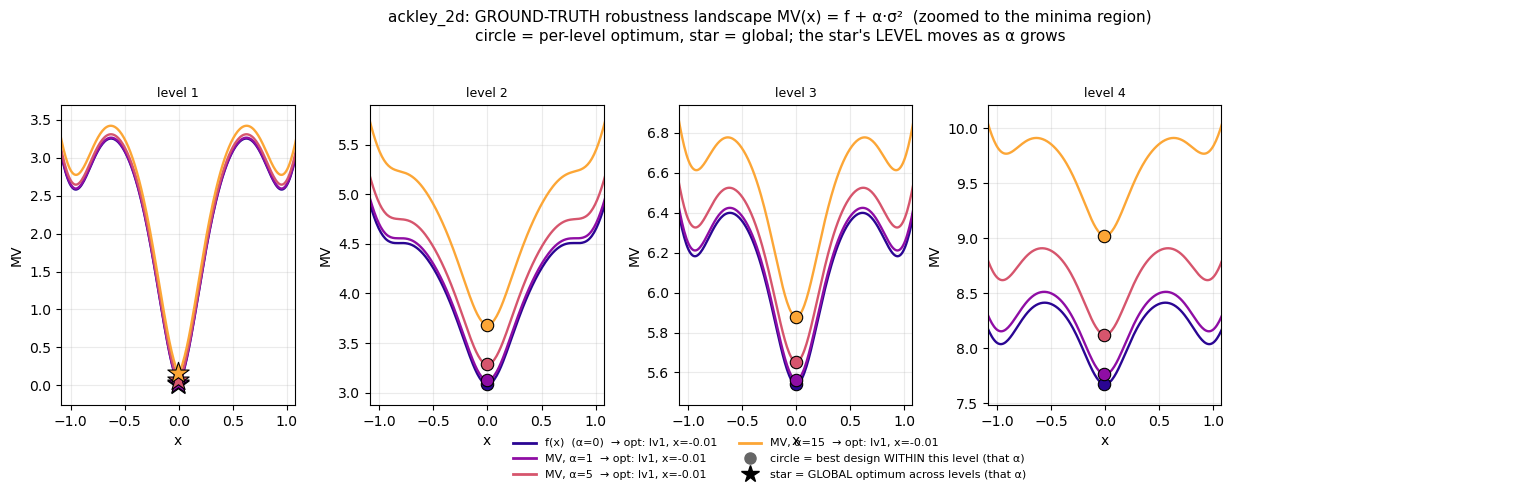

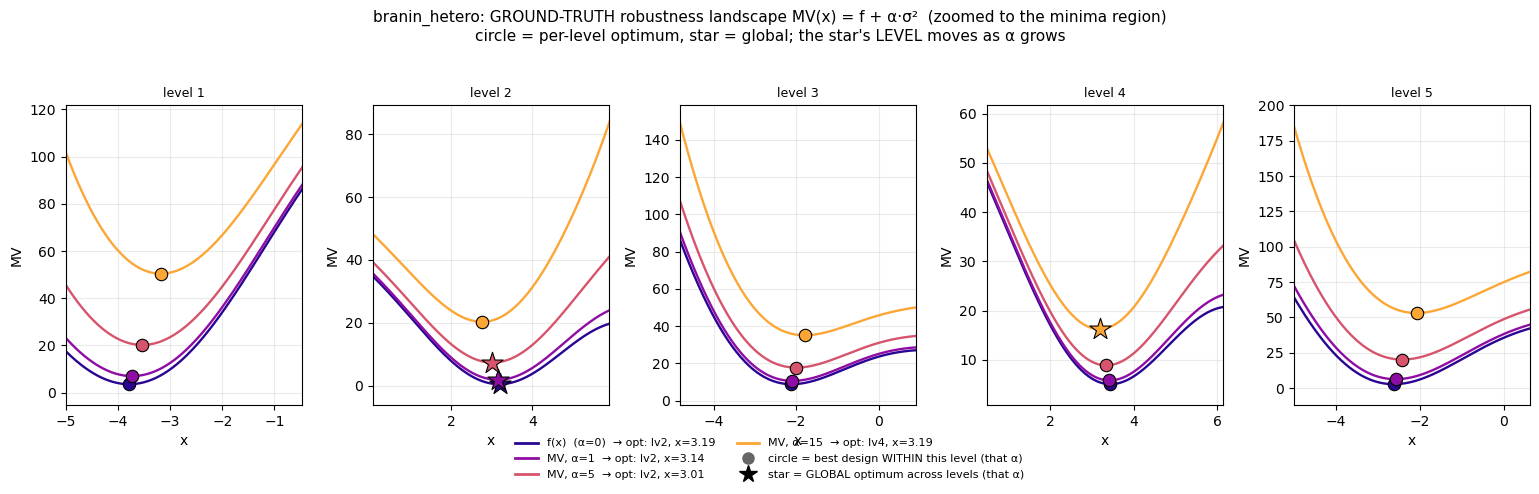

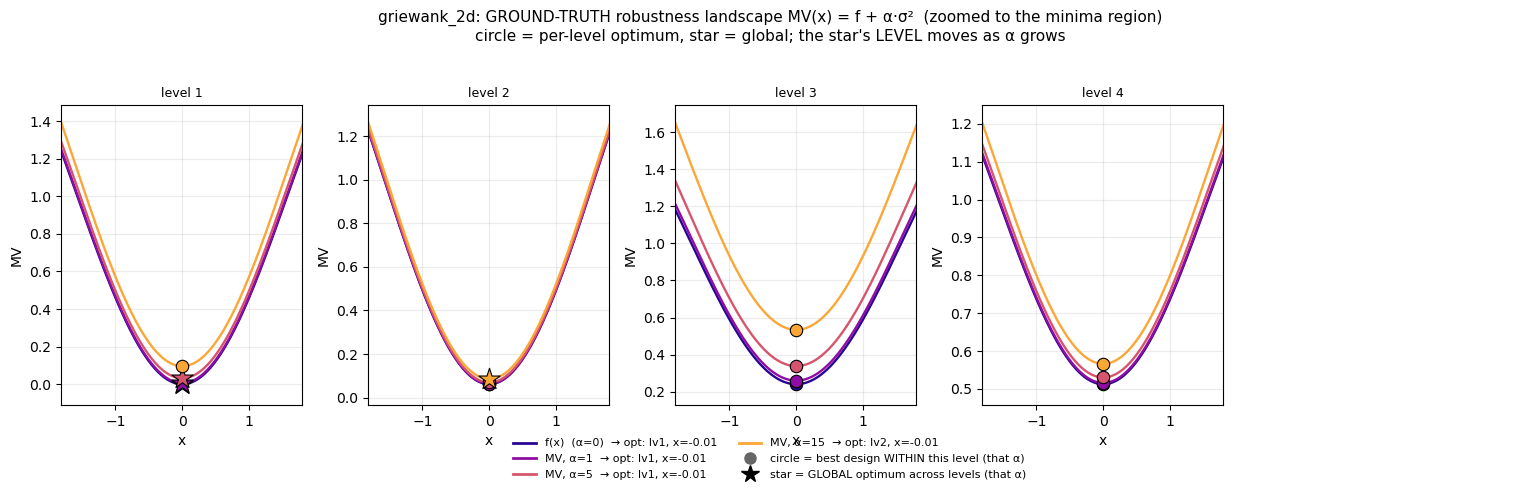

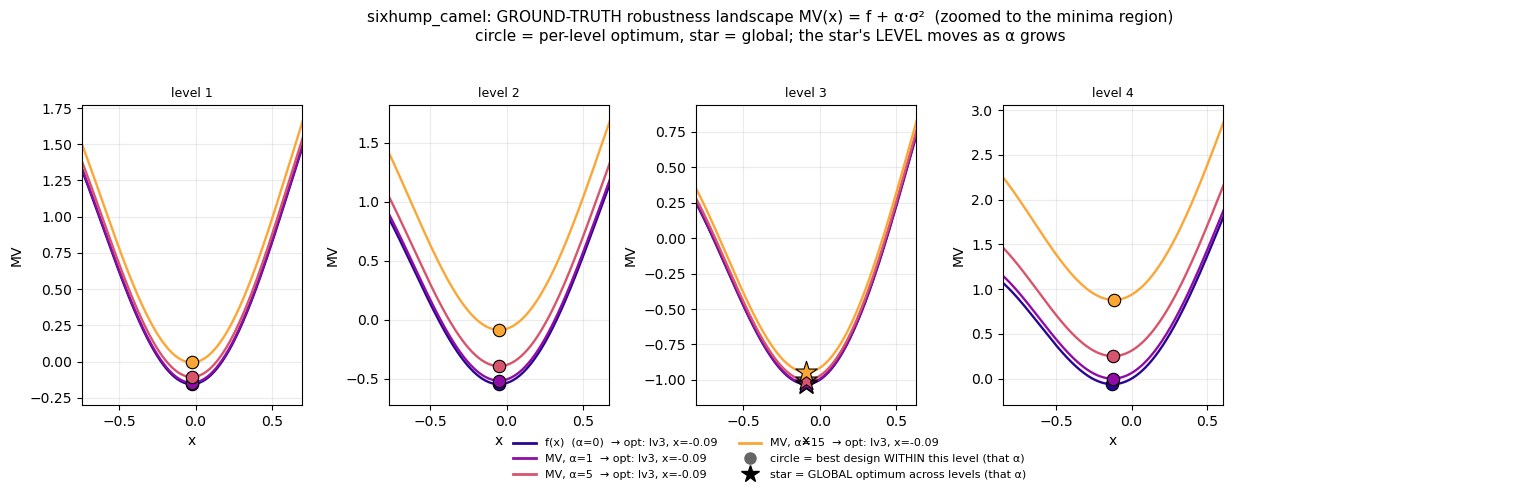

In [16]:
ONE_D = [f for f in FUNCS if P.get(f).d == 1]   # defined here too: this cell runs first
for fn in ONE_D:
    mv_landscape(fn);


#### Hyperparameter-free robustness views: Pareto front, percentiles, and the quantile knob

MV needs an α. These three views need **no exchange rate** (or an interpretable one):

**1. Ground-truth Pareto front + recommendations (`pareto_plot`).** Every design's true (f, σ²) as a
cloud; the black steps are the **Pareto front** — designs where nothing available is both better AND
quieter. Each model's final recommendations are overlaid. Reading: **on the front** = optimal for
*some* risk preference (defensible at any α you might pick); **up-right of the front** = *dominated* —
a strictly better-and-quieter design exists, indefensible at ANY α. Every MV-α just selects one point
along this front, so this single picture subsumes the whole α-sweep.

**2. Percentile framing (`percentile_framing`).** *What "percentile" means here:* each
recommendation is ranked against **every possible design** of that problem —
`f_pct` = % of all designs with a **lower** true f (0 = you recommended the best design there is);
`sigma2_pct` = % of all designs that are **quieter**. So a row reading `f_pct=0.1, sigma2_pct=22`
says: "top 0.1% performance, and 22% of the design space is quieter." Unit-free, α-free, and
directly comparable across problems — the plain-language version of "how good AND how quiet".

**3. Quantile landscape (`quantile_landscape`).** Same idea as the MV landscape but scored by
$q_\tau(x) = f(x) + z_\tau\,\sigma(x)$ — *"the value a single evaluation beats with probability
τ"*. τ=0.5 is the median (= f itself); τ=0.99 asks about your near-worst run. Unlike α (an exchange
rate with no natural scale), **τ is a probability** — "I care about my worst 1% of runs" is a
statement a designer can actually make.

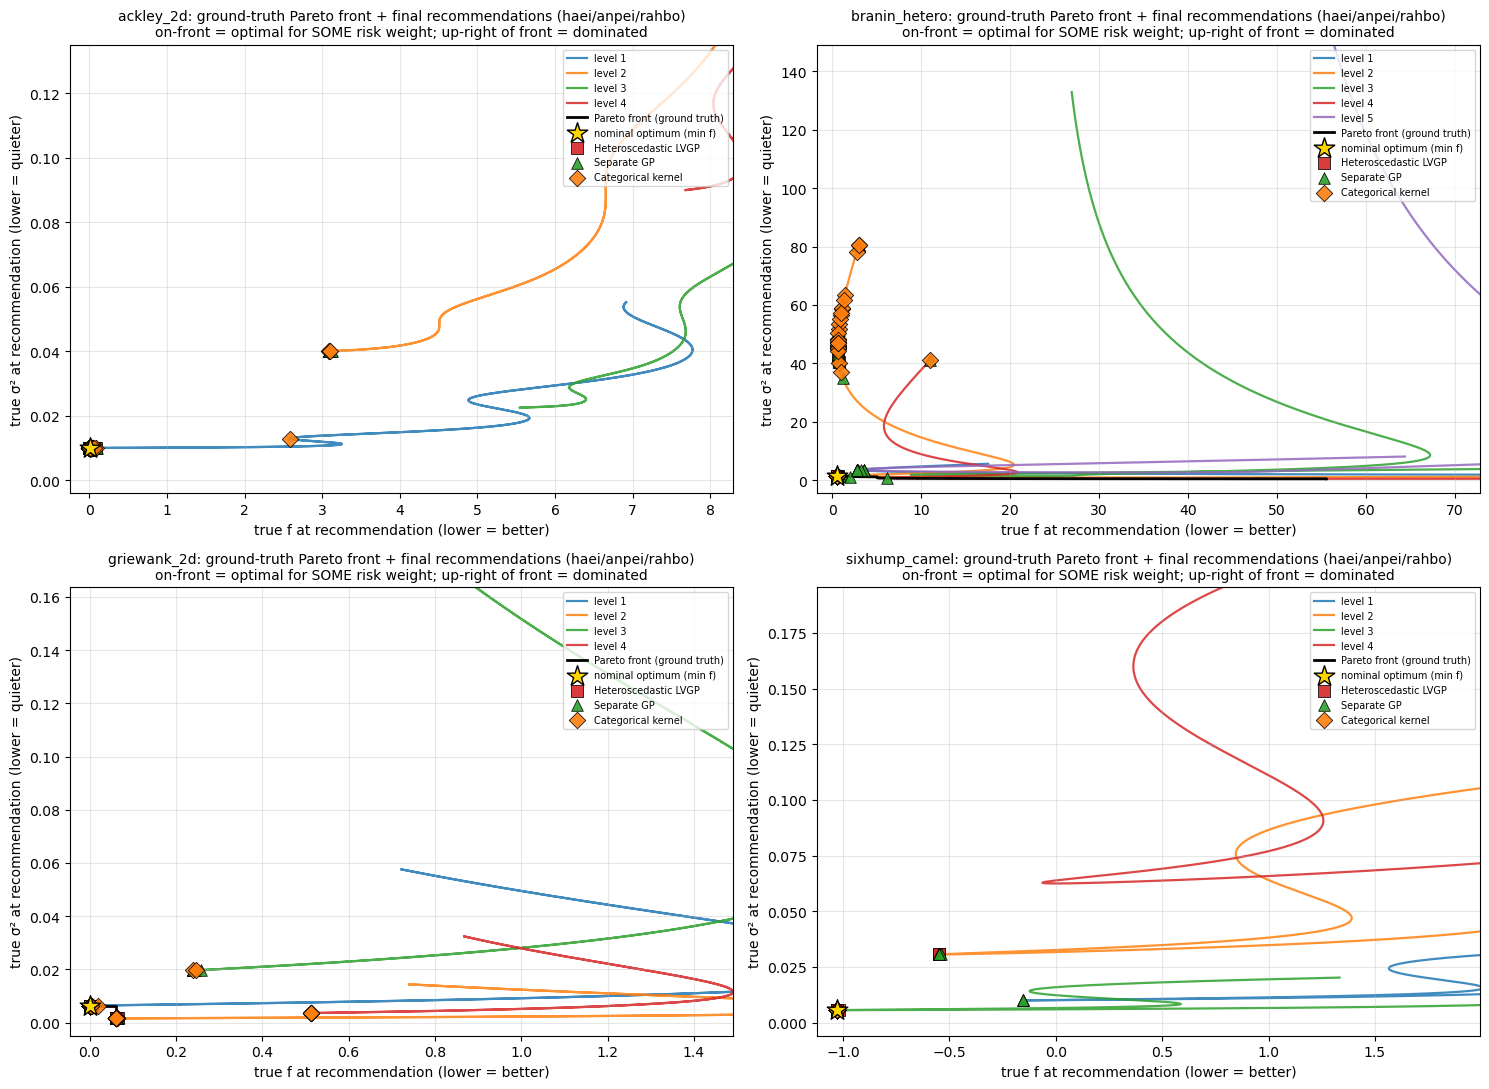

In [17]:
from utils.results import pareto_plot, percentile_framing, quantile_landscape
import matplotlib.pyplot as plt
fig, axes = plt.subplots(2, 2, figsize=(15, 11), squeeze=False)
for ax, fn in zip(axes.ravel(), ONE_D):
    pareto_plot(grid, fn, n_rep=N_REP, acqs=("haei","anpei","rahbo"), ax=ax)
for k in range(len(ONE_D), 4): axes.ravel()[k].axis("off")
plt.tight_layout(); plt.show()

**Ground-truth-only Pareto view** — same trade-off space, *without* the model markers: each
coloured curve is one categorical **level** tracing its (f, σ²) pair as x sweeps the domain
(1-D problems). Shows the structure of the problem itself: which levels ever touch the Pareto
front (black), and where the noisy-but-low-f branches live.

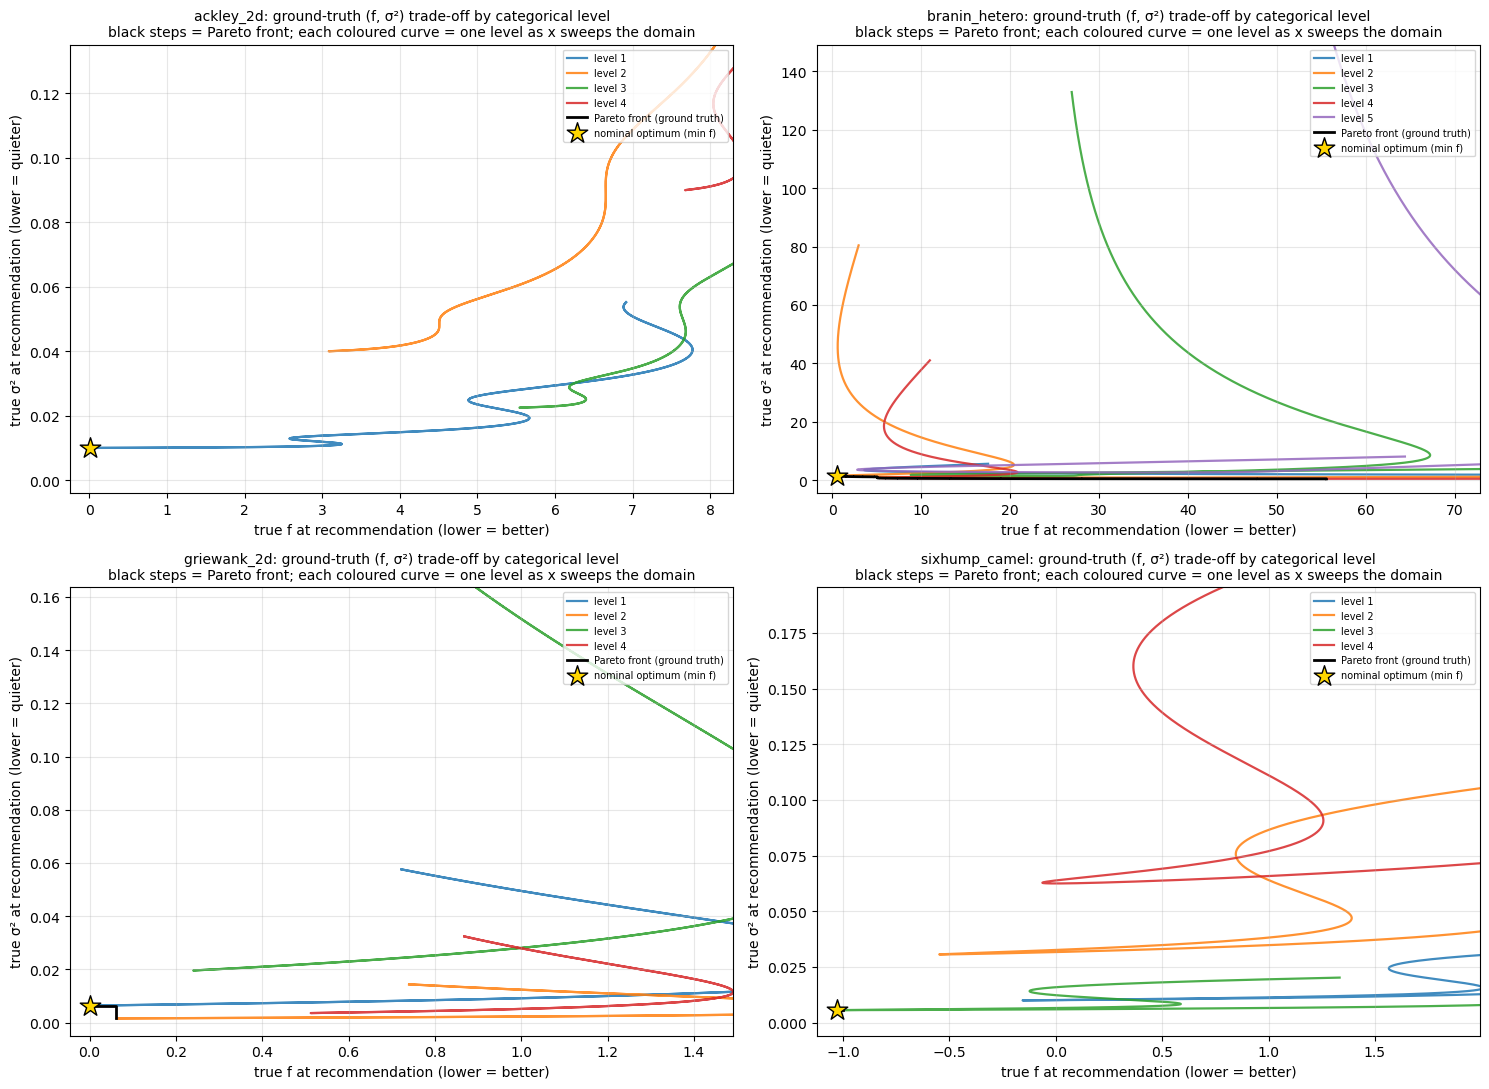

In [18]:
fig, axes = plt.subplots(2, 2, figsize=(15, 11), squeeze=False)
for ax, fn in zip(axes.ravel(), ONE_D):
    pareto_plot(grid, fn, n_rep=N_REP, ax=ax, show_models=False)
for k in range(len(ONE_D), 4): axes.ravel()[k].axis("off")
plt.tight_layout(); plt.show()

In [19]:
# best x% by f / quietest y% -- each recommendation ranked against the WHOLE design space
pf = percentile_framing(grid, functions=DONE, n_rep=N_REP, acqs=("haei","anpei","rahbo"))
style_best(pf, directions={"f_pct":"min","sigma2_pct":"min"}, group_level="problem")

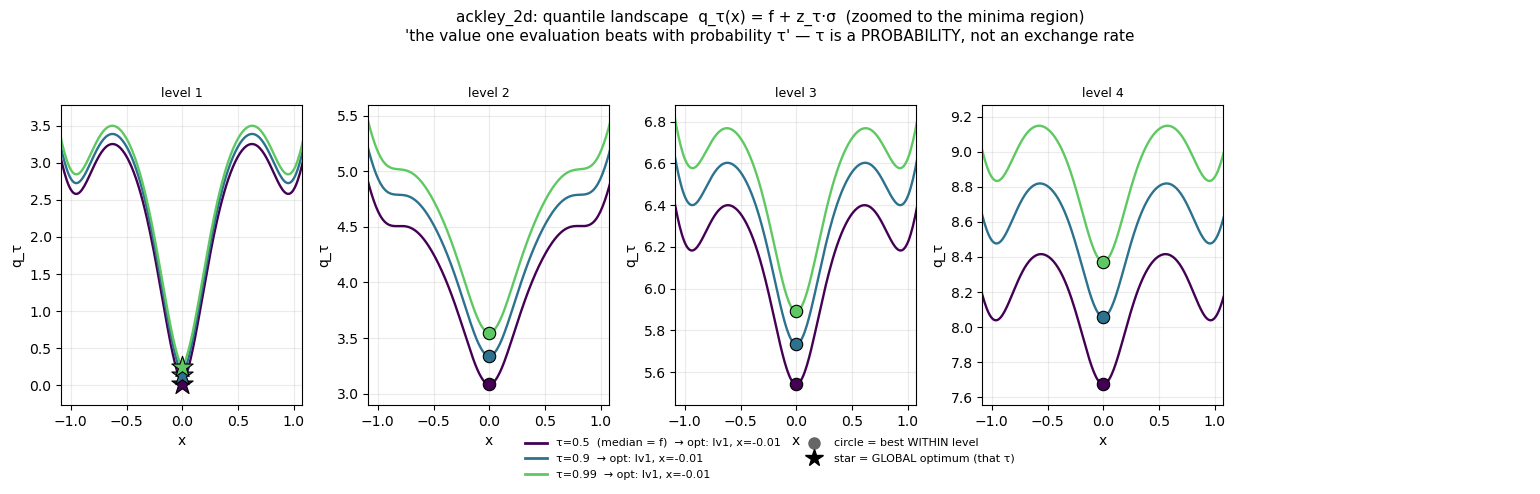

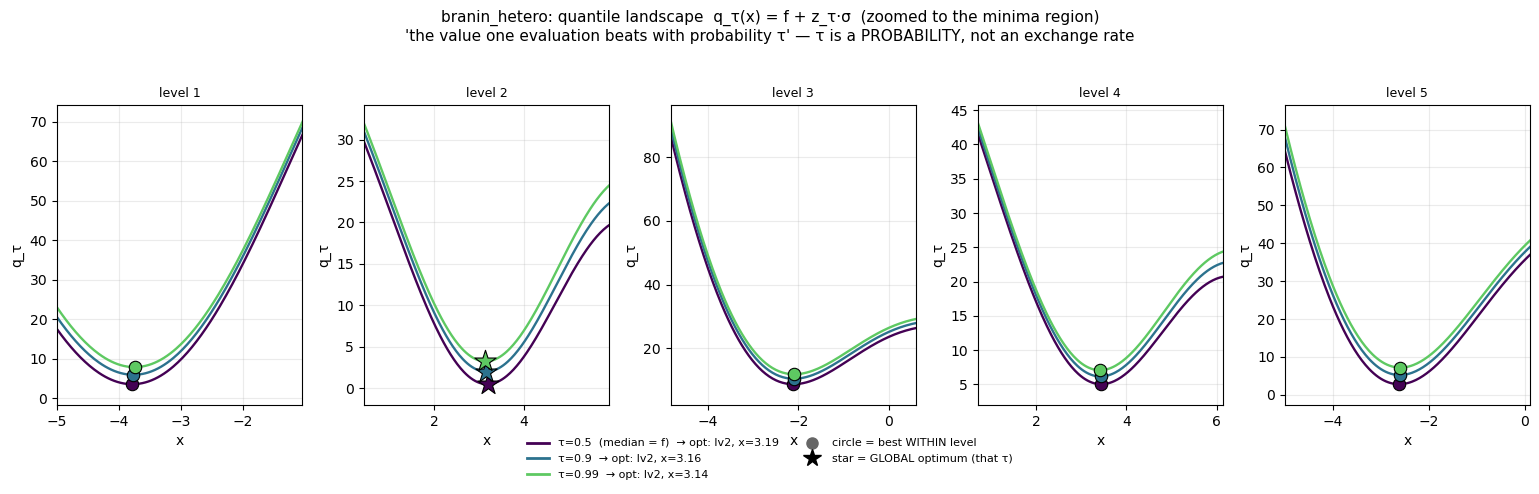

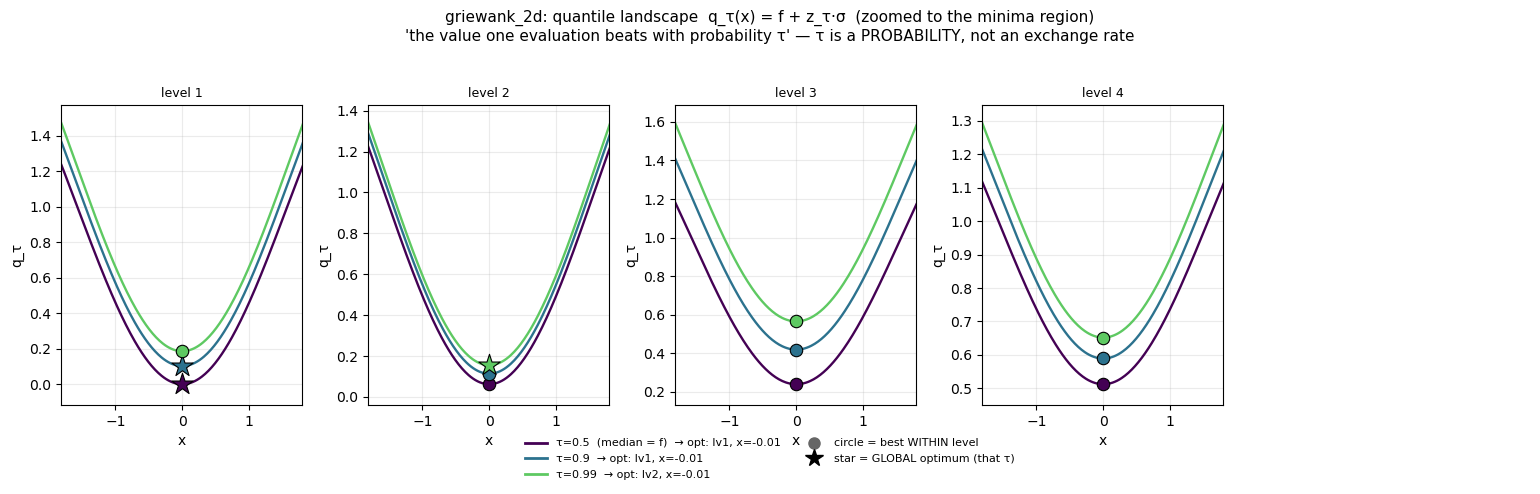

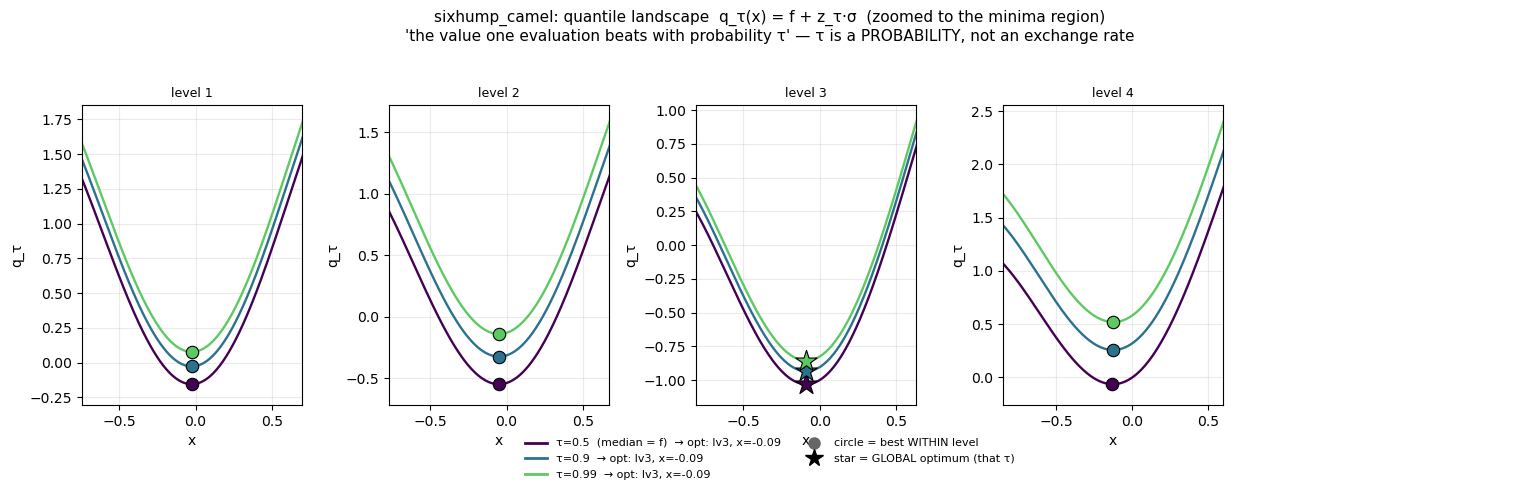

In [20]:
for fn in ONE_D:
    quantile_landscape(fn);

#### Visualizing robustness — three views

The MV tables above give the numbers; these three plots make robustness *visible*:

1. **Landscape (1-D problems — the clearest):** true f(x) per level with its ±2σ noise band, and a
   marker at every model's FINAL recommended design. A robust method's markers sit on **quiet minima**
   (narrow band, green dotted = per-level MV optimum); a noise-blind one recommends the
   **lower-but-noisy twin** (branin: x≈3.2 quiet vs x≈9.4 noisy — watch which models fall for it).
2. **MV convergence:** the running-best of MV = f + α·σ² over iterations — the regret plot's
   robustness analogue (did the method *find* a good-AND-quiet design, and how fast).
3. **Trade-off scatter:** final regret (y) vs σ² at the incumbent (x), one point per (model, acq);
   colour = acquisition, marker = model. Lower-left corner wins both objectives at once.

1-D problems: ['ackley_2d', 'branin_hetero', 'griewank_2d', 'sixhump_camel']


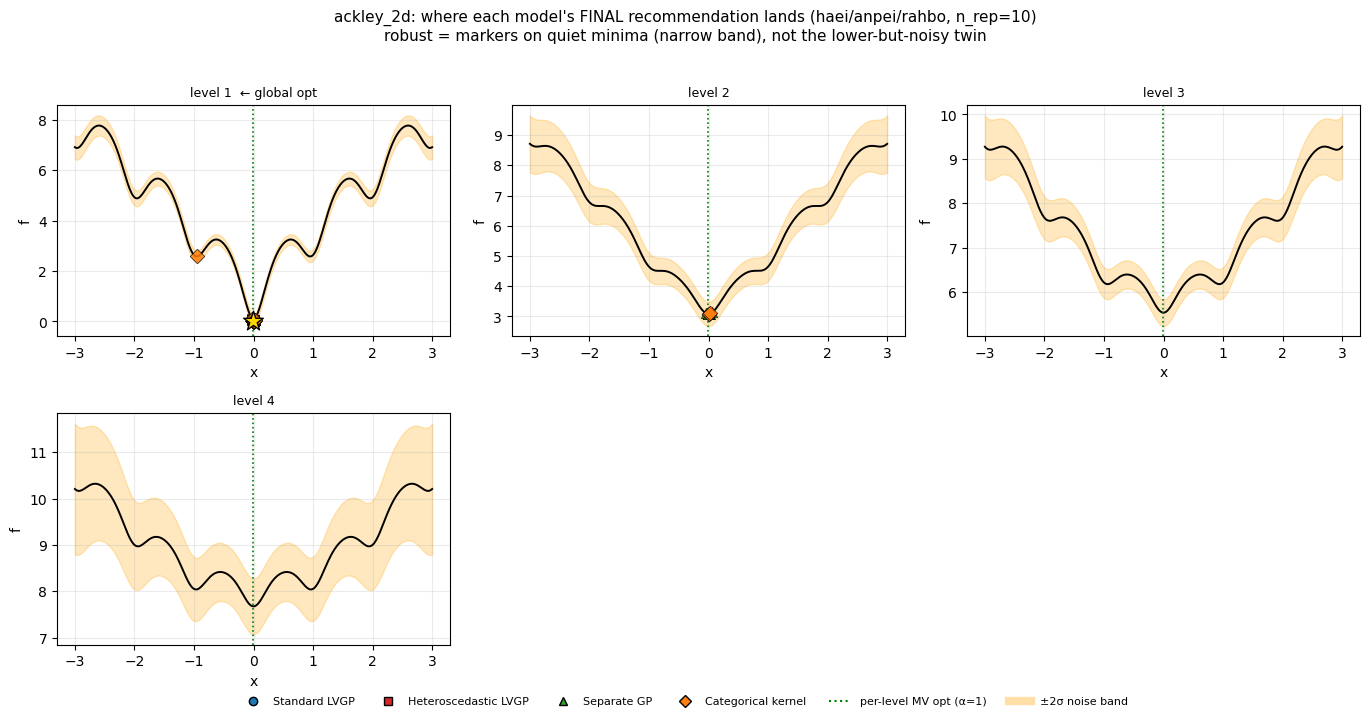

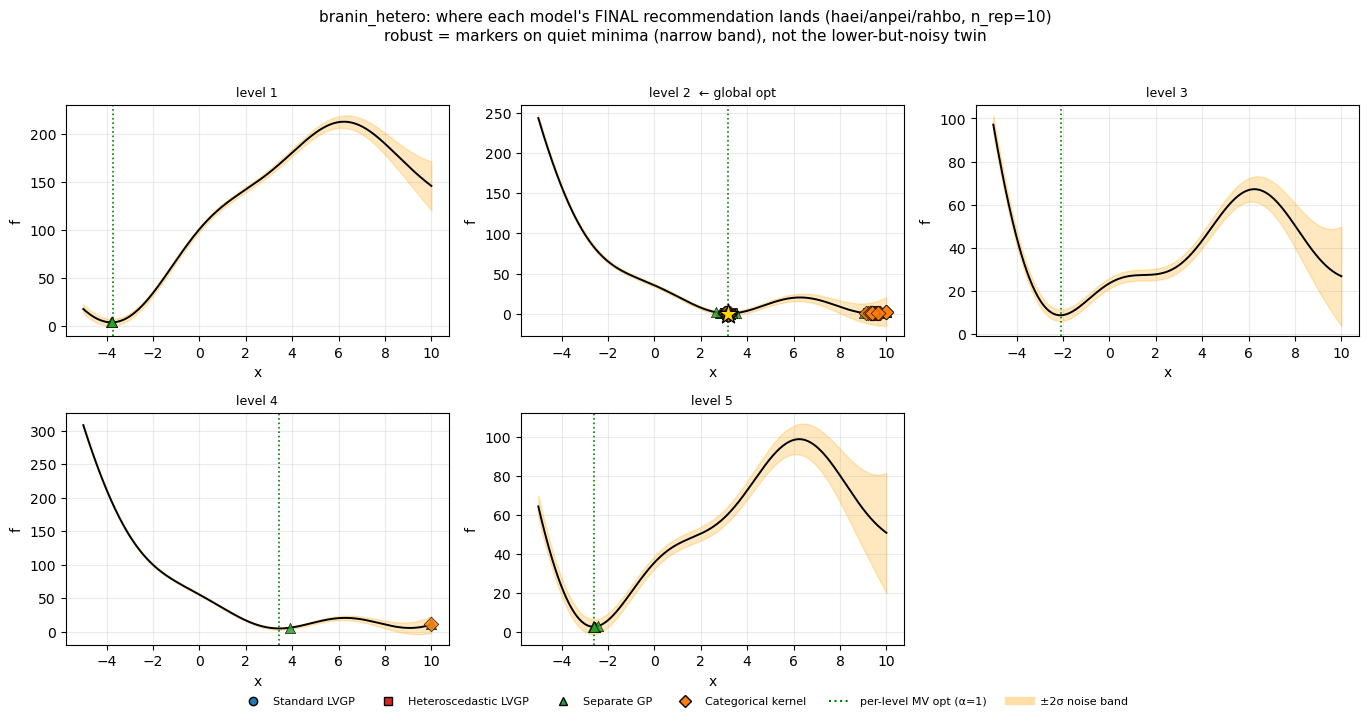

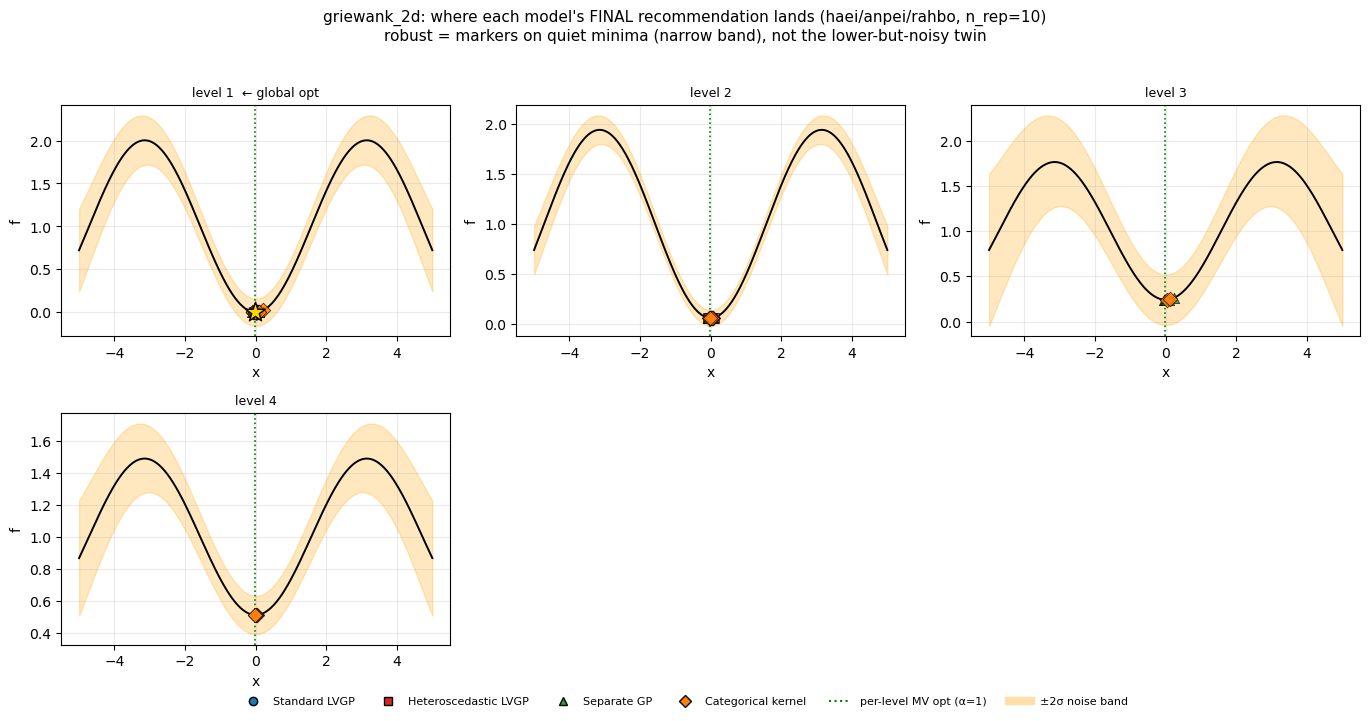

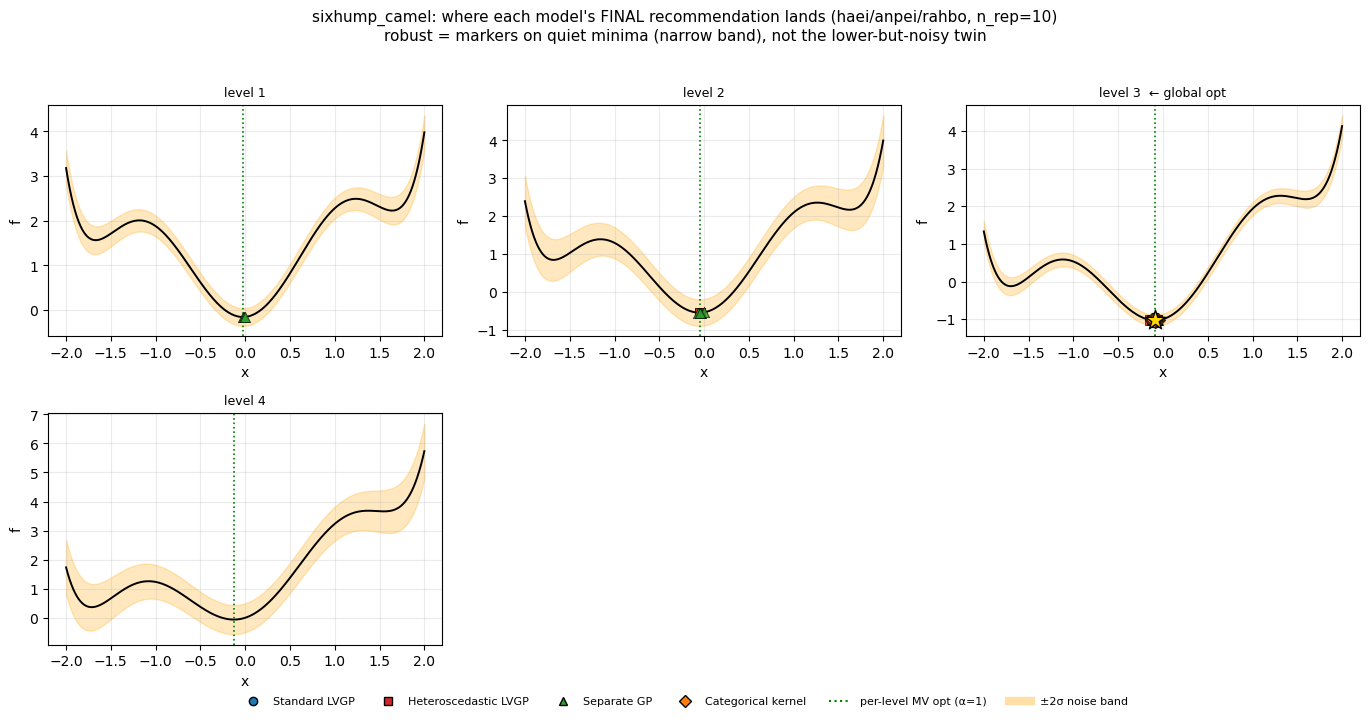

In [21]:
from utils.results import robustness_landscape, tradeoff_scatter
ONE_D = [f for f in FUNCS if P.get(f).d == 1]
print("1-D problems:", ONE_D)
for fn in ONE_D:
    robustness_landscape(grid, fn, n_rep=N_REP, acqs=("haei","anpei","rahbo"));

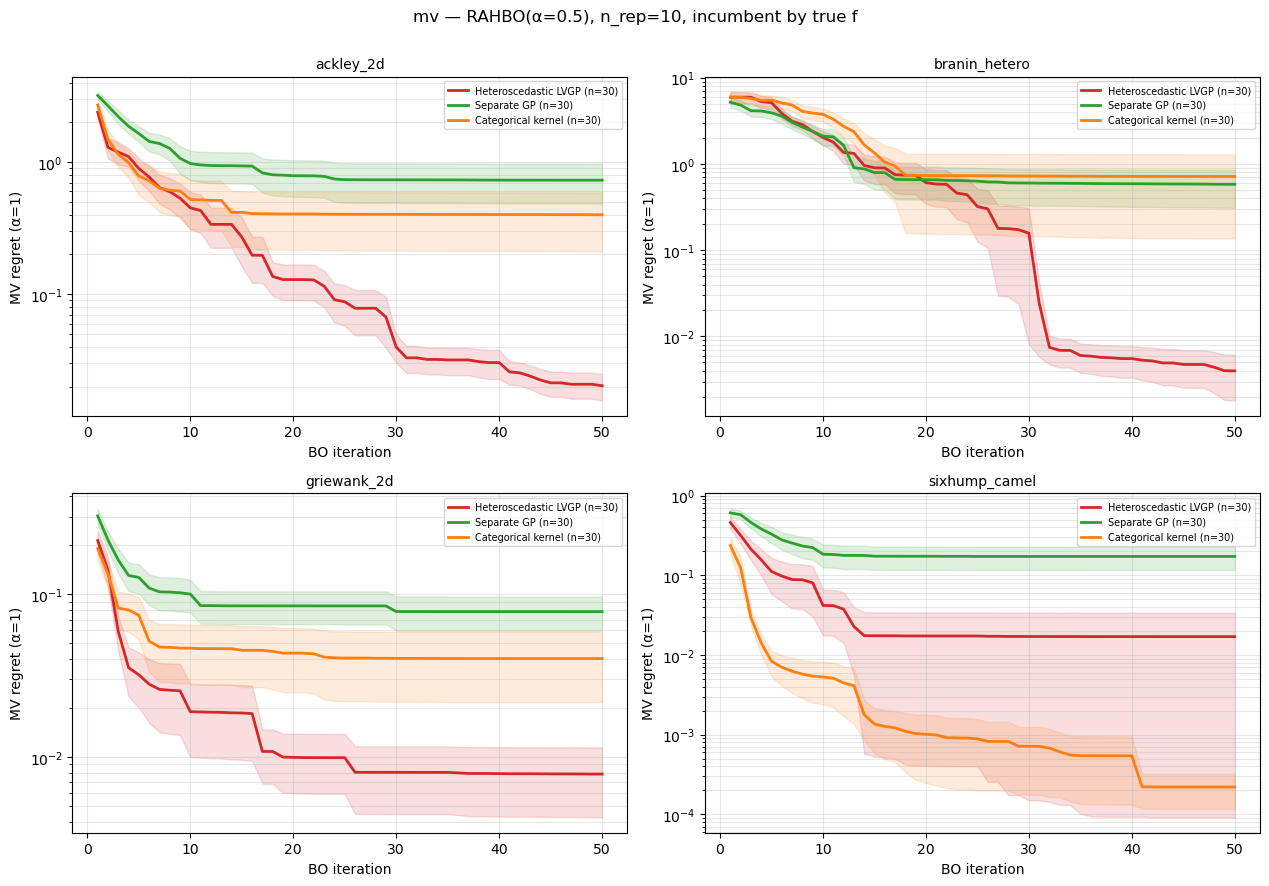

In [22]:
# 2) MV convergence (shown for RAHBO -- the robustness-designed acquisition; edit acf as desired)
facet(grid, "mv", functions=ONE_D, acf="rahbo", param=0.5, n_rep=N_REP, center=CENTER);

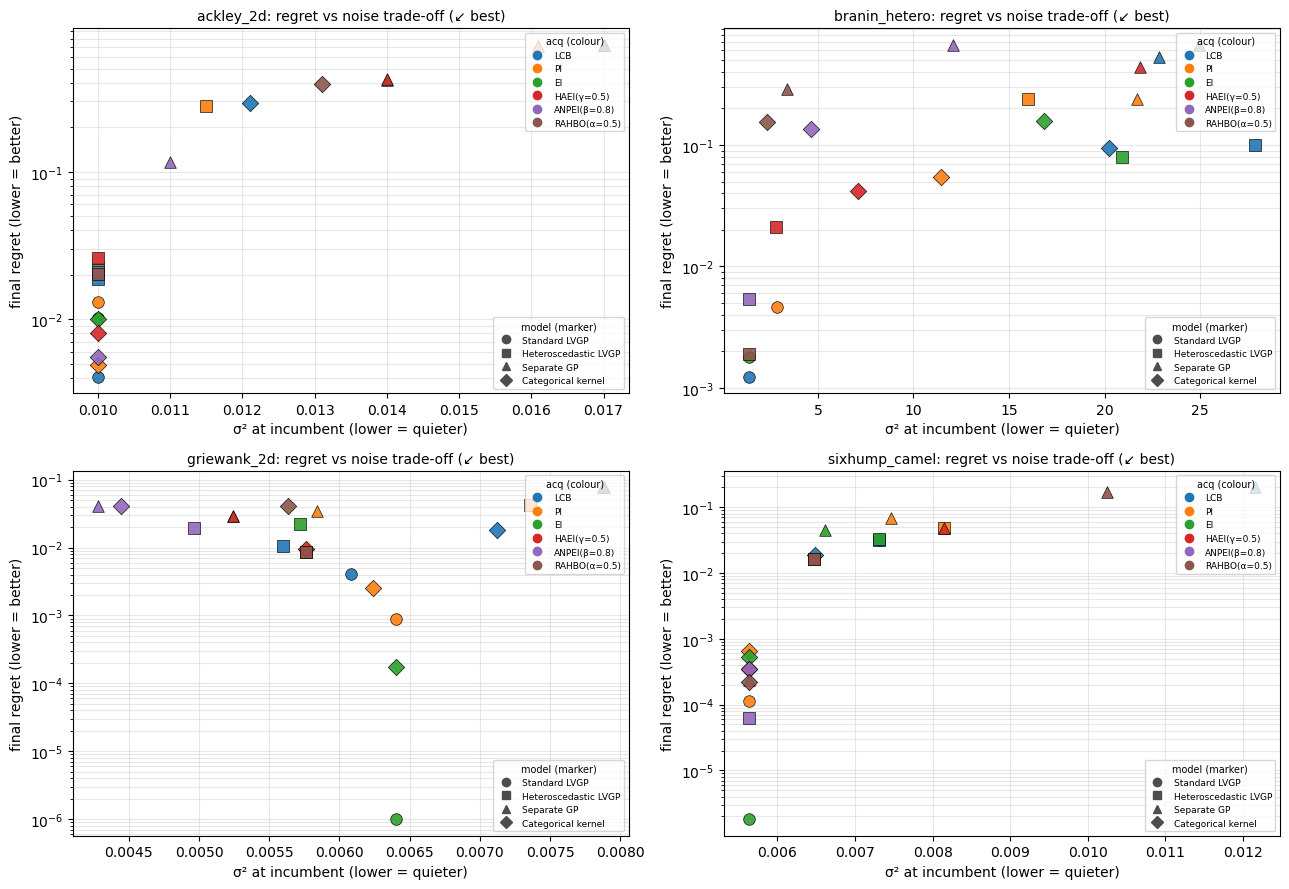

In [23]:
# 3) regret-vs-noise trade-off, one panel per 1-D problem
import matplotlib.pyplot as plt
fig, axes = plt.subplots(2, 2, figsize=(13, 9), squeeze=False)
for ax, fn in zip(axes.ravel(), ONE_D):
    tradeoff_scatter(grid, fn, n_rep=N_REP, ax=ax)
for k in range(len(ONE_D), 4): axes.ravel()[k].axis("off")
plt.tight_layout(); plt.show()

## Part 6 — Acquisition comparison (incl. MV robustness)
**What:** acquisition rankings per model and overall; combined regret / noise / mean-variance (MV)
tables (bold = best per acquisition, green = global best); the MV α-sensitivity sweep; seed-level
ECDFs & boxplots; Excel/LaTeX exports of these tables.
**Why:** the second factor of the grid. For *robust* design the metric is MV = f + α·σ² — a design
is only good if it is good AND quiet; RAHBO/ANPEI/HAEI exist precisely to win this column, so this
is where they must prove it. The α-sweep shows whether the verdict survives different risk weights.
**How:** metrics at the final incumbent; distributions shown because with 5 seeds a mean ± sd can
mislead — the ECDF shows the whole story.

---
# Acquisition-function comparison

Comparing the 6 acquisitions across the 4 problems. Two tables:

**Table 1 — per-problem detail (fixed model).** For one model that supports all 6 acquisitions (default
`heter_LVGP`, the noise-aware flagship), the final **regret** (true = best noiseless value − f\*) and the
final **noisy best value** (the best observed replicate mean — what the optimizer actually saw; it can dip
below f\* on noise), each as mean ± sd over 30 seeds. Fixing the model isolates the acquisition effect.

**Table 2 — the conclusive one.** Regret magnitudes differ by orders of magnitude across problems, so you
*cannot* average raw regret. This table uses **ranks**: within each (problem × model) cell the 6
acquisitions are ranked by mean regret (1 = best), then averaged over all 12 cells (4 problems × the 3
models that support all 6 acquisitions). Lower `mean_rank` = better overall; `wins` = # cells it was best.

In [24]:
ACQ_MODEL = 'separate_gp'          # any model supporting all 6 acqs: heter_LVGP / separate_gp / categorical_kernel
R, N = acquisition_tables(grid, model=ACQ_MODEL, n_rep=N_REP, functions=FUNCS)
print(f'TABLE 1a — final REGRET (true value − f*) · {ACQ_MODEL} · n_rep={N_REP} · mean ± sd over seeds')
display(style_best(R, {c: 'min' for c in FUNCS}))
print(f'TABLE 1b — final NOISY best value (best observed replicate mean) · {ACQ_MODEL} · n_rep={N_REP}')
display(style_best(N, {c: 'min' for c in FUNCS}))

TABLE 1a — final REGRET (true value − f*) · separate_gp · n_rep=10 · mean ± sd over seeds


,ackley_10d,ackley_2d,branin_hetero,golinski,griewank_2d,otl_circuit,piston,rastrigin_6d,sixhump_camel
Separate GP: acquisition,,,,,,,,,
LCB,1.39 ± 0.68,0.726 ± 1.3,0.529 ± 0.88,0 ± 0,0.0769 ± 0.094,0.00142 ± 0.0028,0.00104 ± 0.00071,18.2 ± 9.6,0.2 ± 0.33
PI,1.75 ± 0.94,0.709 ± 1.3,0.238 ± 0.59,0 ± 0,0.0349 ± 0.062,6.94e-05 ± 7e-05,0.000532 ± 0.00038,13.6 ± 3.8,0.0684 ± 0.19
EI,1.75 ± 0.93,0.422 ± 1,0.662 ± 0.95,0 ± 0,0.029 ± 0.049,3.07e-05 ± 6.1e-05,0.001 ± 0.00074,12.2 ± 8,0.0457 ± 0.18
HAEI(γ=0.5),2.4 ± 0.41,0.425 ± 1,0.434 ± 0.74,0 ± 0,0.0288 ± 0.049,3.07e-05 ± 6.1e-05,0.000822 ± 0.00057,9.46 ± 2.4,0.0486 ± 0.15
ANPEI(β=0.8),3.13 ± 1.2,0.116 ± 0.55,0.666 ± 1.1,0 ± 0,0.0413 ± 0.048,0.000162 ± 0.00029,0.00209 ± 0.0007,12.6 ± 3.4,0.000237 ± 0.00041
RAHBO(α=0.5),1.72 ± 1.1,0.723 ± 1.3,0.288 ± 0.78,17.5 ± 28,0.0768 ± 0.094,0.00142 ± 0.0028,0.00123 ± 0.00062,20.4 ± 7.4,0.168 ± 0.3


TABLE 1b — final NOISY best value (best observed replicate mean) · separate_gp · n_rep=10


,ackley_10d,ackley_2d,branin_hetero,golinski,griewank_2d,otl_circuit,piston,rastrigin_6d,sixhump_camel
Separate GP: acquisition,,,,,,,,,
LCB,2.58 ± 0.66,0.661 ± 1.3,-2.88 ± 2,2.33e+03 ± 1.3,0.0235 ± 0.082,2.57 ± 0.0042,0.156 ± 0.0038,23.1 ± 9.4,-0.892 ± 0.31
PI,2.95 ± 0.93,0.662 ± 1.2,-2.16 ± 1.9,2.33e+03 ± 0.93,-0.00703 ± 0.067,2.59 ± 0.0086,0.159 ± 0.0025,18.3 ± 3.8,-1.01 ± 0.18
EI,2.94 ± 0.9,0.375 ± 1,-2.98 ± 2,2.33e+03 ± 1.3,-0.0112 ± 0.055,2.59 ± 0.0053,0.159 ± 0.0035,17.1 ± 7.9,-1.03 ± 0.16
HAEI(γ=0.5),3.62 ± 0.37,0.368 ± 1,-2.7 ± 1.9,2.33e+03 ± 2.8,-0.00875 ± 0.058,2.6 ± 0.0041,0.162 ± 0.002,14.5 ± 2.6,-1.02 ± 0.14
ANPEI(β=0.8),4.36 ± 1.3,0.0812 ± 0.55,0.359 ± 1.2,2.34e+03 ± 5.5,0.0155 ± 0.058,2.6 ± 0.0026,0.164 ± 0.0054,17.5 ± 3.4,-1.07 ± 0.014
RAHBO(α=0.5),2.88 ± 1.1,0.662 ± 1.3,-0.135 ± 1.1,2.36e+03 ± 32,0.0236 ± 0.084,2.57 ± 0.01,0.156 ± 0.0035,25.2 ± 7.3,-0.922 ± 0.28


### Table 2 (conclusive) — overall acquisition ranking by mean rank

In [25]:
rank_df, ncells, models_used = acquisition_ranking(grid, n_rep=N_REP, functions=FUNCS)
print(f'mean rank over {ncells} (problem × model) cells · models: {models_used}')
print('lower mean_rank = better overall')
display(style_best(rank_df, {'mean_rank':'min','median_rank':'min','wins':'max'}))

mean rank over 26 (problem × model) cells · models: ['Heteroscedastic LVGP', 'Separate GP', 'Categorical kernel']
lower mean_rank = better overall


,mean_rank,median_rank,wins,n_cells
acquisition,,,,
PI,3.190000,3.000000,5,26
HAEI(γ=0.5),3.420000,3.000000,3,26
EI,3.500000,4.000000,2,26
RAHBO(α=0.5),3.540000,4.500000,7,26
LCB,3.580000,4.000000,6,26
ANPEI(β=0.8),3.770000,4.000000,3,26


### Full acquisition × method regret table — one table, two emphases
Every (acquisition × model) config on the 4 problems (final true regret, mean ± sd). Instead of two
separate tables: **bold** = best **model within each acquisition**; **green** = the single best
**(acquisition × model) combination** for that problem. Saved to Excel as one sheet per metric/n_rep.

In [26]:
AM = acq_method_regret_table(grid, n_rep=N_REP, functions=FUNCS)
# ONE table: BOLD = best model for each acquisition · GREEN = best (acq × model) combo per problem
style_best_combined(AM, {c: 'min' for c in FUNCS}, group_level='acquisition')


### Same combined table for the **NOISE** (σ² at the incumbent — lower is better)
Same emphasis: **bold** = best model per acquisition, **green** = best combo overall per problem.

In [27]:
AMn = acq_method_table(grid, 'noise', n_rep=N_REP, functions=FUNCS, ground_truth=GROUND_TRUTH)
# same combined style for the NOISE metric (σ² at incumbent, lower = better)
style_best_combined(AMn, {c: 'min' for c in FUNCS}, group_level='acquisition')


### Heatmaps — every acquisition × method, coloured per problem (green = best)
The same grids as heatmaps: colour is the rank within each problem column (scales differ across problems),
the number is the raw value. Regret first, then σ² at the incumbent.

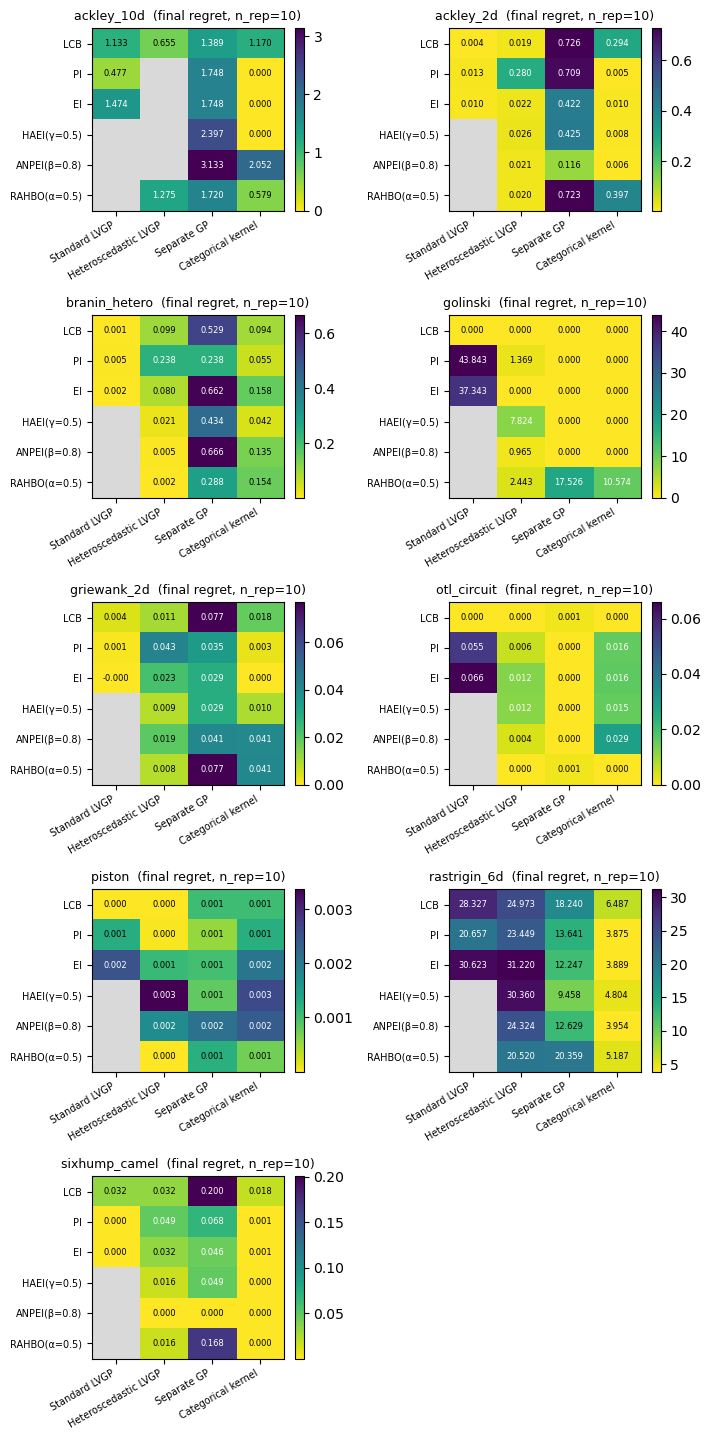

In [28]:
acq_method_heatmap(grid, metric='regret', n_rep=N_REP, functions=FUNCS, ground_truth=GROUND_TRUTH);

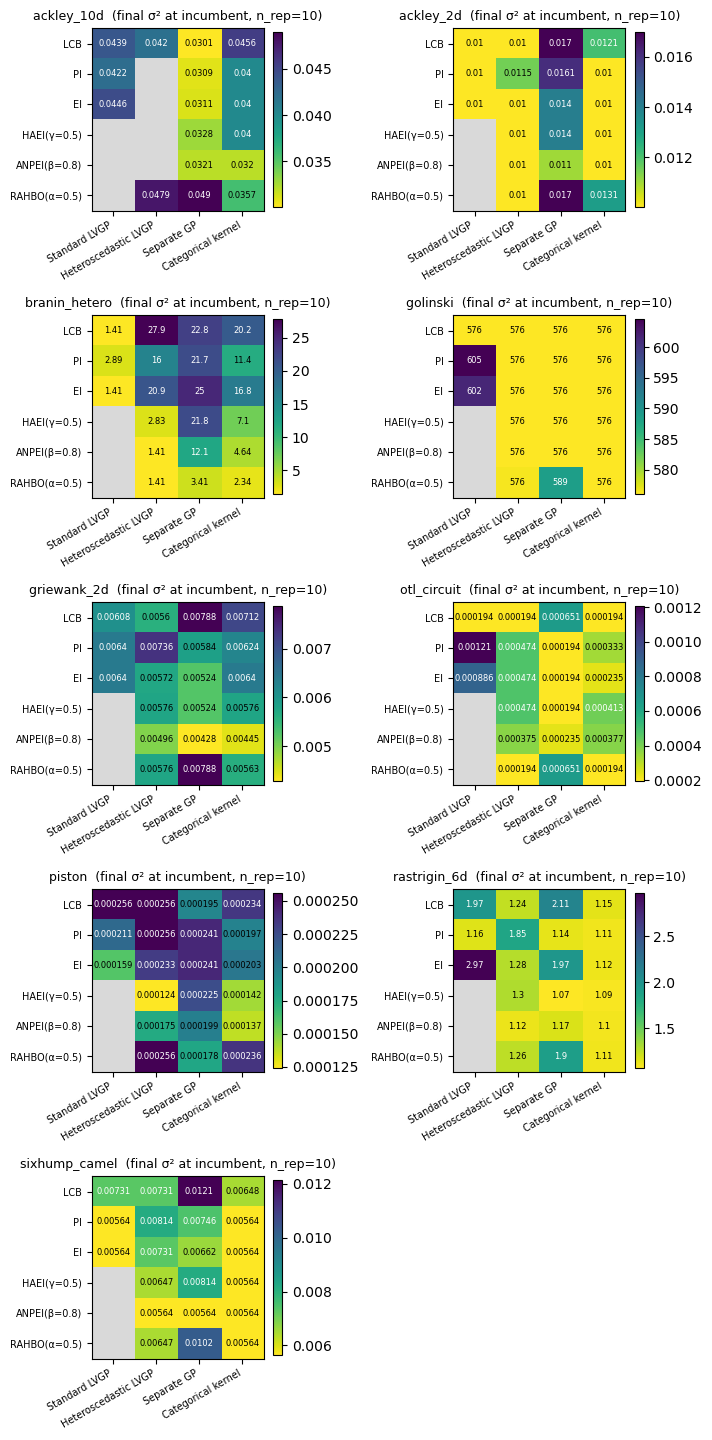

In [29]:
acq_method_heatmap(grid, metric='noise', n_rep=N_REP, functions=FUNCS, ground_truth=GROUND_TRUTH);

### Robustness — mean-variance (RAHBO) metric
Plain regret rewards a great *mean* even in a loud region you couldn't deploy. RAHBO
(Makarova et al., NeurIPS 2021) instead scores the **mean-variance** objective
$\mathrm{MV}(x,\ell)=f(x,\ell)+\alpha\,\sigma^2(x,\ell)$ (lower = better) — low mean **and** low noise.
We can compute the *true* MV-regret exactly, since the true $f$ and $\sigma$ at every sampled point are
stored. `MV*` is the true robust optimum; `α` is the risk-aversion knob (`results.MV_ALPHA`, default 1).

Same combined highlighting; heatmap below.

**Where robustness actually bites — and the α-dependence.** Two problems are *structurally* designed with
the best level ≠ the quietest level: **branin** (lv2 best, σ²=1.41; lv4 quietest, σ²=0.78) and
**griewank_2d** (lv1 best, σ²=0.0064; lv2 quietest, σ²=0.0016). Whether that tension changes any decision
depends on α: switching levels pays only when α > Δf/Δσ² — **≈7.3 for branin, ≈12.9 for griewank**. At α=1
only branin bites, and mainly through a *within-level* trap: branin lv2 has two near-equal minima,
x1=3.18 (f=0.465, σ²=1.4) and x1=9.35 (f=0.595, **σ²=45.7**) — at n_rep=10 the observed-mean s.e. at the
loud one (~2.1) is 16× the mean gap, so noise-blind methods genuinely cannot tell them apart and often park
at the loud minimum. The other problems' noise is small *relative to their mean gaps* (griewank: σ≈0.08 vs
Δf≈0.06+), so MV≈regret there at α=1. The α-sweep below makes this concrete.

In [30]:
AMmv = acq_method_table(grid, 'mv', n_rep=N_REP, functions=FUNCS, ground_truth=GROUND_TRUTH)
style_best_combined(AMmv, {c: 'min' for c in FUNCS}, group_level='acquisition')

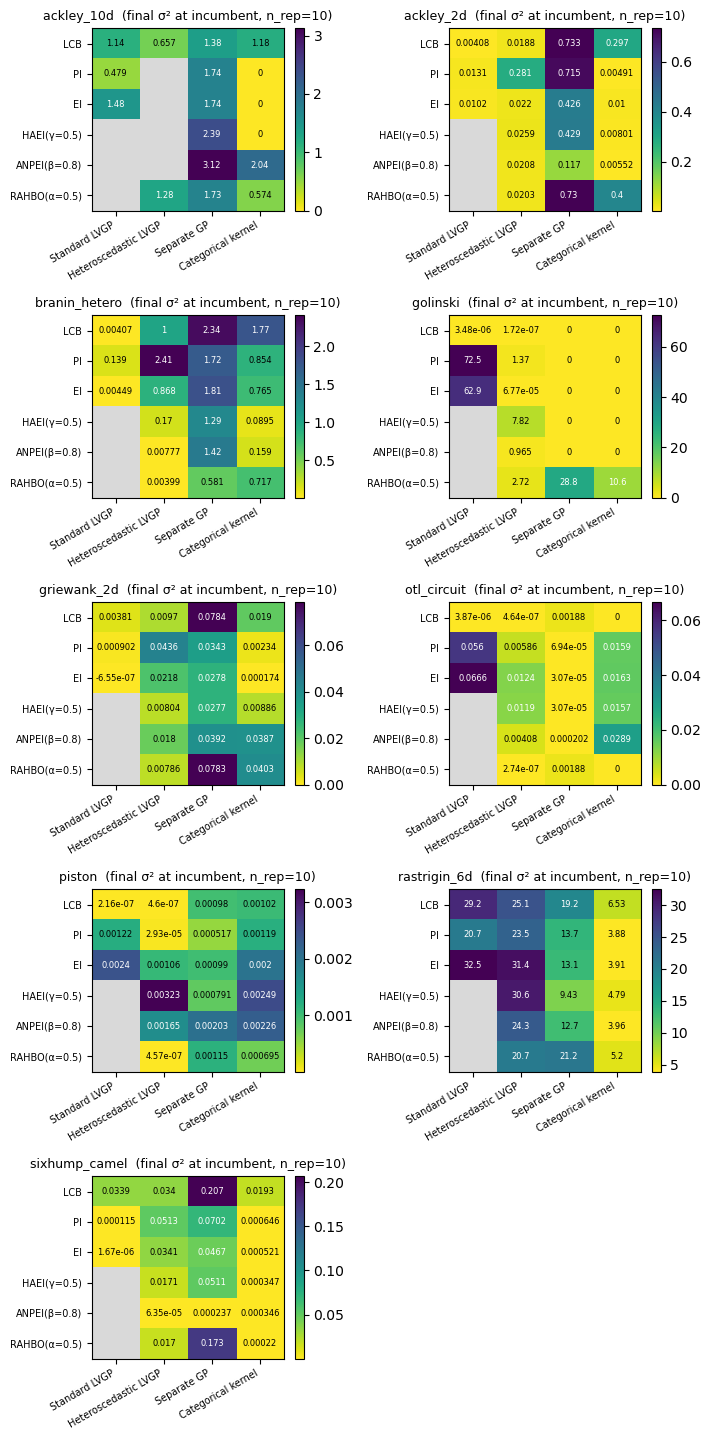

In [31]:
acq_method_heatmap(grid, metric='mv', n_rep=N_REP, functions=FUNCS, ground_truth=GROUND_TRUTH);

#### α-sensitivity of the robustness verdict (`MV_ALPHA ∈ {1, 5, 15}`)
α is a *user preference* (how noise-averse), not a fitted constant — and the verdict moves with it:
the true robust optimum's **level flips** (branin 2→4 above α≈7.3, griewank 1→2 above α≈12.9), and the
best config on griewank flips from `Standard LVGP + EI` to `Heteroscedastic LVGP + ANPEI`. ANPEI's overall
rank strengthens monotonically with α; RAHBO(α₀=0.5)'s does not — its *internal* risk-aversion is milder
than the high-α scoring, so it under-hedges relative to what the metric rewards.

In [32]:
per_problem, acq_ranks = mv_alpha_sweep(grid, alphas=(1, 5, 15), n_rep=N_REP, functions=FUNCS)
print('TRUE robust optimum + best config per problem, per α:')
display(per_problem)
print('acquisition mean-rank (12 cells) vs α — lower is better:')
display(style_best(acq_ranks, {c: 'min' for c in acq_ranks.columns}))

TRUE robust optimum + best config per problem, per α:


mv_star_level  mv_star_x1  \
alpha problem                                    
1     ackley_10d                 1       0.000   
      ackley_2d                  1       0.000   
      branin_hetero              2       3.145   
      golinski                   1       2.600   
      griewank_2d                1       0.000   
      otl_circuit                4     145.215   
      piston                     4      32.000   
      rastrigin_6d               1       0.000   
      sixhump_camel              3      -0.088   
5     ackley_10d                 1       0.000   
      ackley_2d                  1       0.000   
      branin_hetero              2       3.015   
      golinski                   2       2.600   
      griewank_2d                1       0.000   
      otl_circuit                4     145.215   
      piston                     4      32.000   
      rastrigin_6d               1       0.000   
      sixhump_camel              3      -0.088   
15    ackley_10d                 1       0.000   
      ackley_2d                  1       0.000   
      branin_hetero              4       3.180   
      golinski                   2       2.600   
      griewank_2d                2       0.000   
      otl_circuit                4     145.215   
      piston                     4      32.000   
      rastrigin_6d               1       0.000   
      sixhump_camel              3      -0.087   

                                             best_config  best_mv_regret  
alpha problem                                                             
1     ackley_10d                 Categorical kernel + PI          0.0000  
      ackley_2d                      Standard LVGP + LCB          0.0041  
      branin_hetero  Heteroscedastic LVGP + RAHBO(α=0.5)          0.0040  
      golinski                         Separate GP + LCB          0.0000  
      griewank_2d                     Standard LVGP + EI         -0.0000  
      otl_circuit               Categorical kernel + LCB          0.0000  
      piston                         Standard LVGP + LCB          0.0000  
      rastrigin_6d               Categorical kernel + PI          3.8820  
      sixhump_camel                   Standard LVGP + EI          0.0000  
5     ackley_10d                 Categorical kernel + PI          0.0000  
      ackley_2d                      Standard LVGP + LCB          0.0041  
      branin_hetero  Heteroscedastic LVGP + RAHBO(α=0.5)          0.0139  
      golinski                          Separate GP + EI          0.0000  
      griewank_2d                     Standard LVGP + EI         -0.0000  
      otl_circuit               Categorical kernel + LCB          0.0000  
      piston                         Standard LVGP + LCB          0.0000  
      rastrigin_6d               Categorical kernel + PI          3.9104  
      sixhump_camel                   Standard LVGP + EI          0.0000  
15    ackley_10d                 Categorical kernel + PI          0.0000  
      ackley_2d                      Standard LVGP + LCB          0.0041  
      branin_hetero                   Standard LVGP + PI          0.7449  
      golinski                          Separate GP + EI          0.0000  
      griewank_2d    Heteroscedastic LVGP + ANPEI(β=0.8)          0.0001  
      otl_circuit               Categorical kernel + LCB          0.0000  
      piston                  Heteroscedastic LVGP + LCB         -0.0004  
      rastrigin_6d               Categorical kernel + PI          3.9813  
      sixhump_camel                   Standard LVGP + EI          0.0000

acquisition mean-rank (12 cells) vs α — lower is better:


alpha,1,5,15
acquisition,,,
ANPEI(β=0.8),3.540000,3.270000,2.880000
EI,3.500000,3.420000,3.620000
HAEI(γ=0.5),3.380000,3.350000,3.350000
LCB,3.630000,4.110000,4.150000
PI,3.420000,3.350000,3.420000
RAHBO(α=0.5),3.370000,3.330000,3.410000


---
### Distribution across seeds — why `mean ± sd` can mislead
Every table above is a **summary**. On heavy-tailed BO regret that can invert the conclusion. Concrete
case: on Branin, `Heter LVGP + RAHBO` and `Standard LVGP + LCB` have **the same mean MV-regret (~0.0040)**
— they look tied. They are not:

- **median:** RAHBO **0.00023** vs Standard LVGP **0.0035** → RAHBO is typically **~15× more robust**
  (Mann-Whitney p = 1.8e-4, a real difference).
- **worst seed:** RAHBO **0.060** vs Standard LVGP **0.010** → RAHBO's worst case is **6× worse**.

So RAHBO is *usually much better but occasionally fails badly*, while Standard LVGP is *consistently
mediocre*. Those two effects cancel in the mean, which is why it reads as a tie. Use the three views below
(numbers, ECDF, boxplot) rather than the mean alone; and flip `CENTER='median'` to put IQR bands on the
convergence plots.

In [33]:
nan = float('nan')
HEAD = [('standard_LVGP','lcb',nan), ('standard_LVGP','ei',nan),
        ('heter_LVGP','ei',nan), ('heter_LVGP','anpei',0.8), ('heter_LVGP','rahbo',0.5)]
# mean vs MEDIAN vs worst-case + rank test against the best-median config
head_to_head(grid, 'branin_hetero', HEAD, metric='mv', n_rep=N_REP, ground_truth=GROUND_TRUTH)

,mean,median,iqr,worst,n,p_vs_best_median
config,,,,,,
Heteroscedastic LVGP + RAHBO(α=0.5),0.003987,0.000231,0.001577,0.060477,30,—
Heteroscedastic LVGP + ANPEI(β=0.8),0.007768,0.001384,0.006537,0.122193,30,1.3e-01
Standard LVGP + LCB,0.004072,0.003524,0.005671,0.010149,30,1.8e-04
Standard LVGP + EI,0.004493,0.004555,0.005703,0.014296,30,1.3e-04
Heteroscedastic LVGP + EI,0.868299,0.097411,0.825346,7.233644,30,1.5e-09


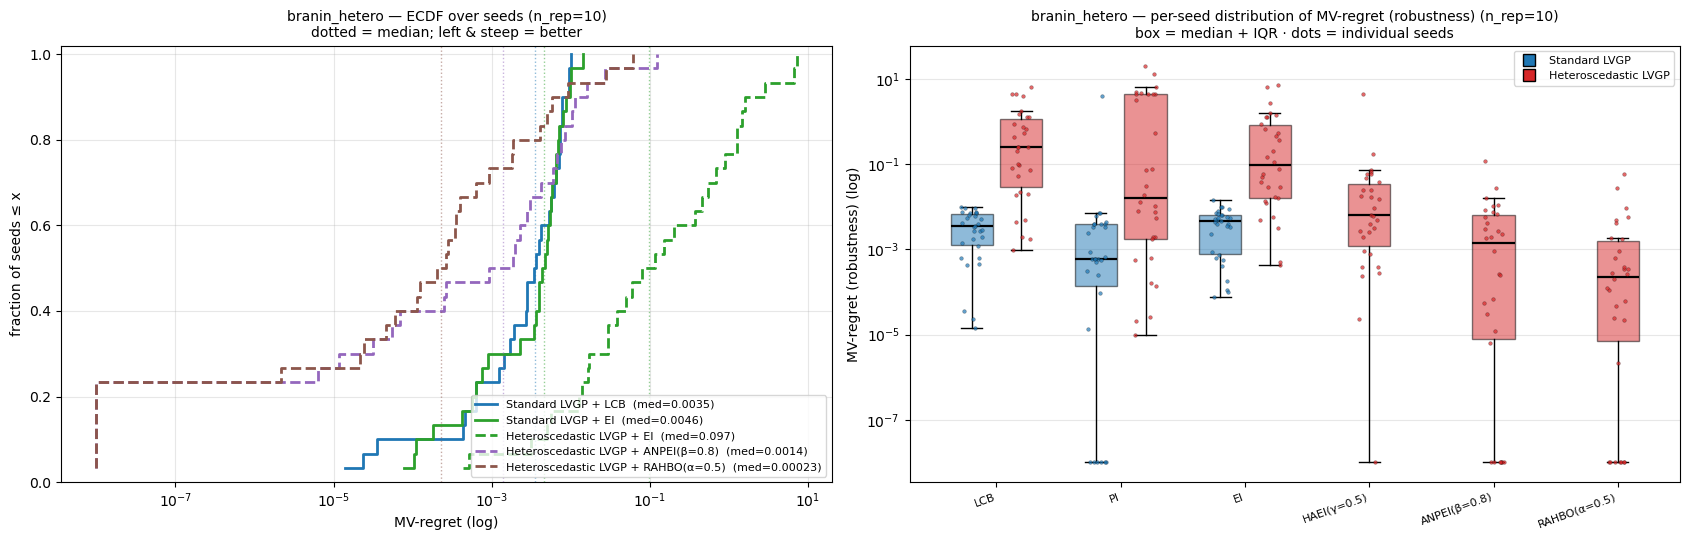

In [34]:
import matplotlib.pyplot as plt
fig, axes = plt.subplots(1, 2, figsize=(17, 5.5))
ecdf(grid, 'branin_hetero', HEAD, metric='mv', n_rep=N_REP, ground_truth=GROUND_TRUTH, ax=axes[0])
seed_boxplot(grid, 'branin_hetero', metric='mv', n_rep=N_REP, ground_truth=GROUND_TRUTH,
             models=['standard_LVGP','heter_LVGP'], ax=axes[1])
fig.tight_layout()

**Reading them.** The **ECDF** is `P(metric ≤ x)`: a curve that rises *far left* is typically better; a
long flat tail on the right = occasional failures. RAHBO reaches the robust optimum on ~23% of seeds
(the leftmost jump) but trails a tail. The **boxplot** shows the same per-acquisition: the noise-aware
boxes (HAEI/ANPEI/RAHBO) sit far lower than the noise-blind ones, with wider whiskers.

### Export the full acquisition × method tables to a **separate** workbook
`acq_method_tables.xlsx` — 8 sheets: {regret, noise} × {n_rep 3, 10} × {best-per-acq, best-combo}
highlightings. (These are kept out of the main `comparison_tables.xlsx`.)

In [35]:
xlsx2 = export_acq_method_excel(grid, path='acq_method_tables.xlsx',
                                n_reps=(3, 10), functions=FUNCS, ground_truth=GROUND_TRUTH)
print('wrote', xlsx2, '— 8 sheets (regret & noise · nrep 3 & 10 · two highlightings)')

wrote acq_method_tables.xlsx — 8 sheets (regret & noise · nrep 3 & 10 · two highlightings)


### LaTeX tables (paper-ready) → `latex/`
Writes the same four acquisition × method tables as booktabs LaTeX (bold = best per acquisition, green =
best combo), plus `latex/main.tex` you can compile to a PDF. `compile_pdf=True` runs pdflatex if present.

In [36]:
tex_files = export_latex_tables(grid, out_dir='../latex', n_reps=(3, 10),
                                functions=FUNCS, ground_truth=GROUND_TRUTH, compile_pdf=True)
print('wrote:'); [print('  ', f) for f in tex_files]

wrote:
   ../latex/regret_nrep03.tex
   ../latex/regret_nrep10.tex
   ../latex/noise_nrep03.tex
   ../latex/noise_nrep10.tex
   ../latex/mv_nrep03.tex
   ../latex/mv_nrep10.tex
   ../latex/tables_main.tex
   ../latex/tables_main.pdf


[None, None, None, None, None, None, None, None]

## Part 7 — Model (surrogate) comparison — the headline
**What:** model rankings aggregated two fair ways (over the 3 shared blind acquisitions; over each
model's own best acquisition), and the (model × acquisition) leaderboard.
**Why:** the central question of the study — is the heteroscedastic LVGP the best surrogate, and
under which acquisition.
**How:** mean rank across problems (rank, not raw regret, so hard problems don't dominate).
**Caveat:** these rankings inherit the regret metric, hence the engine confound (Part 3 note); read
them TOGETHER with Part 8, which removes the loop from the comparison.

---
# Method (surrogate) comparison

Same idea as the acquisition tables, for the 4 surrogate models. **Fairness note:** `standard_LVGP` only
runs the 3 noise-blind acquisitions, and `heter_LVGP`'s edge needs a noise-aware one — so a single fixed
acquisition can't rank the models fairly. The conclusive table therefore reports two angles.

**Table 1 — per-problem detail** at a shared acquisition (EI, which all 4 models run): final regret and
noisy best value, mean ± sd over seeds.

**Table 2 — conclusive model ranking**, from two fair angles (regret can't be averaged across problems →
ranks):
- `mean_rank_bestacq`: each model uses its **own best acquisition** per problem, then the 4 models are
  ranked — "each model at its best". This is the fair view for `heter_LVGP`.
- `mean_rank_blind`: all 4 models on the **shared noise-blind** acquisitions only (apples-to-apples).

**Table 3 — the combined leaderboard**: every (model × acquisition) configuration ranked within each
problem, averaged. Top row = the single best configuration overall. This pools *both* factors.

In [37]:
Rm, Nm = method_tables(grid, acf='ei', n_rep=N_REP, functions=FUNCS)
print(f'METHOD TABLE 1a — final REGRET · acq=EI · n_rep={N_REP} (all 4 models; EI is noise-blind)')
display(style_best(Rm, {c: 'min' for c in FUNCS}))
print(f'METHOD TABLE 1b — final NOISY best value · acq=EI · n_rep={N_REP}')
display(style_best(Nm, {c: 'min' for c in FUNCS}))

METHOD TABLE 1a — final REGRET · acq=EI · n_rep=10 (all 4 models; EI is noise-blind)


,ackley_10d,ackley_2d,branin_hetero,golinski,griewank_2d,otl_circuit,piston,rastrigin_6d,sixhump_camel
acq=EI: model,,,,,,,,,
Standard LVGP,1.47 ± 0.73,0.0102 ± 0.0098,0.00181 ± 0.0076,37.3 ± 13,-6.54e-07 ± 4.2e-07,0.0659 ± 0.03,0.0025 ± 0.0021,30.6 ± 9.4,1.81e-06 ± 5.8e-06
Heteroscedastic LVGP,—,0.022 ± 0.031,0.0802 ± 0.058,6.39e-05 ± 7.9e-05,0.0225 ± 0.048,0.0121 ± 0.014,0.00109 ± 0.0006,31.2 ± 2.5,0.0324 ± 0.12
Separate GP,1.75 ± 0.93,0.422 ± 1,0.662 ± 0.95,0 ± 0,0.029 ± 0.049,3.07e-05 ± 6.1e-05,0.001 ± 0.00074,12.2 ± 8,0.0457 ± 0.18
Categorical kernel,4.44e-16 ± 0,0.01 ± 0.0092,0.158 ± 0.39,0 ± 0,0.000174 ± 0.00025,0.0163 ± 0.014,0.00205 ± 0.00054,3.89 ± 2.2,0.000521 ± 0.00094


METHOD TABLE 1b — final NOISY best value · acq=EI · n_rep=10


,ackley_10d,ackley_2d,branin_hetero,golinski,griewank_2d,otl_circuit,piston,rastrigin_6d,sixhump_camel
acq=EI: model,,,,,,,,,
Standard LVGP,2.56 ± 0.73,0.0265 ± 0.0095,0.372 ± 0.43,2.39e+03 ± 13,0.0113 ± 0.0036,2.67 ± 0.03,0.164 ± 0.0025,35.6 ± 9.4,-1.02 ± 0.0037
Heteroscedastic LVGP,—,0.0388 ± 0.031,0.486 ± 0.47,2.35e+03 ± 7.9e-05,0.0327 ± 0.049,2.62 ± 0.014,0.162 ± 0.00095,36.2 ± 2.5,-0.986 ± 0.13
Separate GP,2.94 ± 0.9,0.375 ± 1,-2.98 ± 2,2.33e+03 ± 1.3,-0.0112 ± 0.055,2.59 ± 0.0053,0.159 ± 0.0035,17.1 ± 7.9,-1.03 ± 0.16
Categorical kernel,1.07 ± 0.026,-0.0355 ± 0.025,-3.3 ± 1.5,2.33e+03 ± 0.93,-0.0427 ± 0.013,2.62 ± 0.018,0.163 ± 0.002,8.69 ± 2.1,-1.07 ± 0.013


### Table 2 (conclusive) — model ranking, two fair angles

In [38]:
mrank = method_ranking(grid, n_rep=N_REP, functions=FUNCS)
display(style_best(mrank, {'mean_rank_bestacq':'min','mean_rank_blind':'min','wins_bestacq':'max'}))

,mean_rank_bestacq,wins_bestacq,mean_rank_blind,usual_best_acq
model,,,,
Standard LVGP,2.000000,5,2.330000,LCB
Categorical kernel,2.110000,3,2.040000,PI
Heteroscedastic LVGP,2.560000,0,2.640000,RAHBO(α=0.5)
Separate GP,3.330000,1,2.890000,LCB


### Table 3 (conclusive, both factors) — best (model × acquisition) configurations

In [39]:
lb = method_acq_leaderboard(grid, n_rep=N_REP, functions=FUNCS)
print(f'combined leaderboard — mean rank of each config over {len(FUNCS)} problems (lower = better)')
display(style_best(lb.head(12), {'mean_rank':'min','best_rank':'min','wins':'max'}))

combined leaderboard — mean rank of each config over 9 problems (lower = better)


> **Reading these — regret is not the whole story.** These tables rank by **regret** (finding the
> mean-optimum). By that metric the simple **Standard LVGP with a noise-blind acquisition dominates** on
> these 4 problems — the heteroscedastic machinery doesn't pay off for pure optimization here. But
> `RAHBO`/`ANPEI` optimize a **risk-averse** objective (mean *and* variance), so judging them by mean
> regret alone undersells them: see the **σ² at the incumbent** panels — the noise-aware methods settle on
> **quieter** designs, which is their actual goal. So "best" depends on whether you want the lowest-*mean*
> point or a low-*noise* point you can deploy.

## Part 8 — Model quality & robustness (loop-light verdict)
**What:** MAE / RRMSE / coverage(90%) / interval-score at the incumbent recommendation, noise-capture
error, and the robust-design table (true f, true σ², MV of the FINAL recommended design).
**Why:** these score the **model**, not the BO loop — the fair cross-engine comparison, and the
place where heteroscedastic modeling should show its designed-for advantages: *calibration*
(cov90 ≈ 0.9 vs the noise-blind model's overconfidence) and *robust recommendations* (low MV).
**How:** computed from stored `mu/s/r_at_est` at `X_min_est` (last 25 iterations) against the true
f and σ² — no refitting; details and metric definitions in the section header below.

# Model quality & robustness — MAE / RRMSE / coverage / interval score

**Why these metrics, alongside regret.** Regret measures *optimization outcome*, which mixes the
surrogate with the BO loop (acquisition optimizer, engine, noise stream) — and the two MATLAB models
run in a different loop than the two python models, so cross-model regret carries an engine confound.
The metrics below are computed from the **stored posterior at the incumbent recommendation**
(`mu/s/r_at_est` @ `X_min_est`, last 25 iterations) against the **true** f and **true** noise — they
score the *model*, with far less loop sensitivity, and need no re-running.

| metric | what it measures | good |
|---|---|---|
| MAE | \|posterior mean − true f\| at the recommendation | low |
| RRMSE | RMSE / std(f over sampled points) — comparable across problems | low |
| cov90 | fraction of \|error\| ≤ 1.645·s — **calibration** | ≈ 0.90 (1.0 = underconfident, 0 = overconfident) |
| IS90 | 90% interval score (Gneiting): width + miss penalties, normalized | low |
| nMAE | \|predicted aleatoric r − true σ²\| / mean σ² — **noise capture** | low (NaN for noise-blind models) |

First table: the three noise-blind acquisitions (ei/lcb/pi) that **all four models** run —
apples-to-apples.

In [40]:
from utils.results import model_quality_table, model_quality_ranks, design_robustness_table
bench = grid          # grid already excludes the aux python-LVGP models (see setup cell)
DONE = [f for f in FUNCS if f in ('ackley_2d','branin_hetero','golinski','griewank_2d',
                                  'otl_circuit','sixhump_camel')]
mq = model_quality_table(bench, functions=DONE, n_rep=N_REP, acqs=("ei","lcb","pi"))
style_best(mq, directions={"MAE":"min","RRMSE":"min","IS90":"min","nMAE":"min","cov90":"max"},
           group_level="problem")

### Conclusive: mean rank across problems (1 = best; cov90 ranked by |cov90−0.90|)

In [41]:
rk = model_quality_ranks(mq)
style_best(rk, directions={c:"min" for c in rk.columns})

,MAE,RRMSE,cov90,IS90,nMAE,mean_rank
model,,,,,,
Categorical kernel,1.333333,1.333333,2.166667,1.166667,2.166667,1.633333
Separate GP,2.166667,2.166667,1.916667,2.166667,1.333333,1.950000
Heteroscedastic LVGP,2.833333,2.666667,1.916667,2.666667,2.500000,2.516667
Standard LVGP,3.666667,3.833333,4.000000,4.000000,nan,3.875000


### Same metrics on the noise-aware acquisitions (HAEI/ANPEI/RAHBO — 3 models)
This is the regime the heteroscedastic LVGP was designed for.

In [42]:
mq_na = model_quality_table(bench, functions=DONE, n_rep=N_REP, acqs=("haei","anpei","rahbo"))
display(style_best(mq_na, directions={"MAE":"min","RRMSE":"min","IS90":"min","nMAE":"min","cov90":"max"},
                   group_level="problem"))
style_best(model_quality_ranks(mq_na), directions={c:"min" for c in model_quality_ranks(mq_na).columns})

,MAE,RRMSE,cov90,IS90,nMAE,mean_rank
model,,,,,,
Categorical kernel,1.666667,1.666667,1.583333,1.833333,2.166667,1.783333
Separate GP,2.166667,2.000000,2.333333,2.166667,1.666667,2.066667
Heteroscedastic LVGP,2.166667,2.333333,2.083333,2.000000,2.166667,2.150000


## Robust-design quality — what does each model actually RECOMMEND?

For robust design the question isn't only "how low is f at the recommendation" but **"how noisy is the
design it recommends"**. Table: true f, true σ², and MV = f + α·σ² at the FINAL recommended design
(median over seeds). Left: blind acqs (4 models, fair). Right: noise-aware acqs (3 models) — where a
robustness-aware model *should* trade a little f for much lower σ².

In [43]:
rob_blind = design_robustness_table(bench, functions=DONE, n_rep=N_REP, acqs=("ei","lcb","pi"))
rob_aware = design_robustness_table(bench, functions=DONE, n_rep=N_REP, acqs=("haei","anpei","rahbo"))
print("BLIND acqs (4 models)");  display(style_best(rob_blind, group_level="problem"))
print("NOISE-AWARE acqs (3 models)"); style_best(rob_aware, group_level="problem")

BLIND acqs (4 models)


NOISE-AWARE acqs (3 models)


## Reading this analysis (methodology notes)

1. **Regret across the 4 models is engine-confounded** — MATLAB's loop exploits the optimum harder
   than the python loop (verified: it affects `separate_gp` even more than the LVGPs). Use regret to
   compare *within* an engine, and the model-quality/robustness tables above to compare *models*.
2. **`true_best_sampled` regret vs recommendation quality**: the regret plots use the best *sampled*
   point; the tables above use the *recommended* design. For noisy problems the recommendation is the
   deliverable — a model can luck into sampling a good point while recommending a bad one.
3. **Calibration (cov90) is where heteroscedasticity shows**: the noise-blind Standard LVGP is
   drastically over-confident (cov90 ≈ 0.0–0.3) because it fits replicate means as if noiseless; the
   heteroscedastic LVGP restores ≈ 0.9–1.0 coverage. That — not raw MAE — is the designed-for win.
4. **5 seeds** → prefer medians/ranks over means; treat single-problem differences as suggestive,
   cross-problem consistency as the real signal.
5. Aggregate tables average over acquisitions; per-acquisition views (earlier sections) remain the
   place to check acquisition-specific behaviour.

## Part 9 — Exports
**What/How:** all comparison tables to Excel (`comparison_tables.xlsx`, plus the acquisition×method
workbook from Part 6) and paper-ready LaTeX to `latex/`. Regenerate any time; outputs are derived
purely from the stored result cells.

### Export all tables to Excel
Writes every acquisition/method/leaderboard table to one formatted workbook (`comparison_tables.xlsx`):
7 sheets, the **best cell in each column bold + green-highlighted**, headers frozen, columns auto-width.

In [44]:
xlsx, _ = export_comparison_tables(grid, path='comparison_tables.xlsx',
                                   n_rep=N_REP, functions=FUNCS, acq_model=ACQ_MODEL)
print('wrote', xlsx, '— 7 sheets; best value per column is bold + highlighted')

wrote comparison_tables.xlsx — 7 sheets; best value per column is bold + highlighted
